In [1]:
import pandas as pd

In [2]:
data=pd.read_csv('cristina_.csv')

C:\Users\akshaya\AppData\Local\Temp\ipykernel_158228\2257867071.py:1: DtypeWarning: Columns (67,73,75,87,92,93,99,150,152,153,155,156,162,164,170,179,181,182,183,184,185,186,187,188,189,195,353,354) have mixed types. Specify dtype option on import or set low_memory=False.
  data=pd.read_csv('cristina_.csv')


In [3]:
data

,id,pi_sog,pi_stw,true_wind_dir,true_wind_speed,relative_wind_speed,relative_wind_direction,caa,corrected_power,rw,...,rob_garbage_cat_a_plastic,rob_garbage_cat_b_organic,rob_garbage_cat_c_domestic,rob_garbage_cat_e_ashes,qty_sludge_disposed,steaming_time_m_e_lng,reefer_power_consumption,wind_direction_side,sea_direction_side,tot_sludge_removed
0,267431,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000,0.59974,0.00000,0.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5646698,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
2,5702140,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
3,5973584,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,4645.8,NaN,NaN,NaN
4,6031516,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,6500.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5677,310909,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000,0.59974,0.00000,0.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5678,356893,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000,0.59243,0.00000,0.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5679,1615213,-5.87023,-7.69819,73.5759,10.14635,16.21709,-28.64583,0.13358,30414.11145,-24544.29572,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5680,1552181,-100.00000,-100.00000,325.0000,7.71660,6.73266,40.00000,0.42723,14073.00000,22472.69360,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
data.columns.to_list()

['id',
 'pi_sog',
 'pi_stw',
 'true_wind_dir',
 'true_wind_speed',
 'relative_wind_speed',
 'relative_wind_direction',
 'caa',
 'corrected_power',
 'rw',
 'ref_speed',
 'imo',
 'vessel',
 'id_vessel',
 'gid',
 'voyage',
 'corrected_date',
 'report_date_time',
 'report_date_time_offset',
 'report_type',
 'status',
 'lat',
 'long',
 'latitude',
 'longitude',
 'me_foc',
 'cargo_total',
 'total_steaming_time',
 'me_fuel_only_steaming_time',
 'miles_by_gps',
 'oil_cyl',
 'speed_by_log',
 'speed_by_gps',
 'rpm',
 'slip',
 'wind_direction',
 'wind_speed',
 'draft_aft',
 'draft_fwd',
 'displacement',
 'course_at_sea',
 'wave_height',
 'sea_direction',
 'cargo_total_teu',
 'ambient_temp',
 'sw_temp',
 'miles_by_speed_log',
 'eta_port_code',
 'eta_date_time',
 'eta_date_time_offset',
 'eta_port',
 'time_change',
 'time_sea',
 'temp_min',
 'temp_max',
 'requested_speed',
 'rem_dist_to_pilot',
 'rem_time_to_pilot',
 'total_unplnd_stpge_tech',
 'total_unplnd_stpge_ope_wx',
 'reefers_positive_plugge

In [5]:
data.shape

(5682, 356)

In [7]:

data['report_date_time'] = pd.to_datetime(data['report_date_time'])


min_date = data['report_date_time'].min()
last_date = data['report_date_time'].max()

print("Minimum Date:", min_date)
print("Last Date:", last_date)


Minimum Date: 2015-09-17 00:00:00
Last Date: 2024-09-08 12:00:00


In [8]:
nan_count_port = data['port'].isna().sum()

# Get unique counts in the port column
unique_count_port = data['port'].nunique()

print(f"NaN Count in 'port' column: {nan_count_port}")
print(f"Unique Count in 'port' column: {unique_count_port}")


NaN Count in 'port' column: 480
Unique Count in 'port' column: 81


In [9]:
duplicates = data[data.duplicated()]

# Print duplicate rows if any
if not duplicates.empty:
    print("Duplicate rows found:")
    print(duplicates)
else:
    print("No duplicate rows found.")


No duplicate rows found.


In [10]:
most_frequent_port = data['port'].value_counts().idxmax()
most_frequent_port_count = data['port'].value_counts().max()

print(f"The most frequent port is: {most_frequent_port} with {most_frequent_port_count} occurrences.")


The most frequent port is: KING ABDULLAH PORT with 454 occurrences.


In [11]:
df_filtered = data.dropna(subset=['status'])
df_filtered.shape

(5483, 356)

In [41]:
df=df_filtered[['imo','vessel','corrected_date','report_date_time','status','lat','long','latitude',
 'longitude','me_foc','cargo_total','total_steaming_time','me_fuel_only_steaming_time','miles_by_gps','speed_by_log',
 'speed_by_gps', 'rpm', 'slip', 'wind_direction', 'wind_speed', 'draft_aft', 'draft_fwd',"eta_port",'port_code','port','steaming_time_me_rsdl_vls',
 'steaming_time_me_rsdl_hs',"manvrng_miles_by_gps",
 'steaming_time_me_rsdl_uls',
 'steaming_time_me_dstlt_vls',
 'steaming_time_me_dstlt_uls',
 'steaming_time_me_tnktnr_dstlt_vls',
 'steaming_time_me_mdo',
 'steaming_time_aux_1',
 'steaming_time_aux_2',
 'steaming_time_aux_3',
 'steaming_time_aux_4',
 'steaming_time_aux_5',
 'steaming_time_sh_gen',
 'steaming_time_tg',
 'fuel_me_rsdl_vls',
 'fuel_me_rsdl_hs',
 'fuel_me_rsdl_uls',
 'fuel_me_dstlt_vls',
 'fuel_me_dstlt_uls',
 'fuel_me_mdo',
 'fuel_me_tnktnr_dstlt_vls',
 'fuel_aux_rsdl_vls',
 'fuel_aux_rsdl_hs',
 'fuel_aux_rsdl_uls',
 'fuel_aux_dstlt_vls',
 'fuel_aux_dstlt_uls',
 'fuel_aux_tnktnr_dstlt_vls',
 'fuel_aux_mdo',
 'fuel_boiler_rsdl_vls',
 'fuel_boiler_rsdl_hs',
 'fuel_boiler_rsdl_uls',
 'fuel_boiler_dstlt_vls',
 'fuel_boiler_dstlt_uls',
 'fuel_boiler_tnktnr_dstlt_vls',
 'fuel_boiler_mdo',
 'power_kw']]

In [43]:
df

,imo,vessel,corrected_date,report_date_time,status,lat,long,latitude,longitude,me_foc,...,fuel_aux_tnktnr_dstlt_vls,fuel_aux_mdo,fuel_boiler_rsdl_vls,fuel_boiler_rsdl_hs,fuel_boiler_rsdl_uls,fuel_boiler_dstlt_vls,fuel_boiler_dstlt_uls,fuel_boiler_tnktnr_dstlt_vls,fuel_boiler_mdo,power_kw
1,9465241,MSC CRISTINA,2023-10-12 04:00:00,2023-10-12 12:00:00,IN PORT,NaN,NaN,NaN,NaN,0.0,...,7.7,NaN,NaN,NaN,NaN,NaN,NaN,1.1,NaN,NaN
2,9465241,MSC CRISTINA,2023-11-20 04:00:00,2023-11-20 12:00:00,IN PORT,NaN,NaN,NaN,NaN,0.0,...,4.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,9465241,MSC CRISTINA,2023-01-14 02:24:00,2023-01-14 05:24:00,DRIFTING,NaN,NaN,NaN,NaN,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN
4,9465241,MSC CRISTINA,2023-03-02 09:00:00,2023-03-02 12:00:00,DRIFTING,3643N,03442E,36.716667,34.700000,1.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.7,NaN,NaN
5,9465241,MSC CRISTINA,2024-03-20 06:30:00,2024-03-20 12:00:00,DRIFTING,0702N,07941E,7.033333,79.683333,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5675,9465241,MSC CRISTINA,2019-08-25 00:00:00,2019-08-25 12:00:00,AT SEA,1108N,07449E,11.133333,74.816667,144.7,...,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,33283.0
5676,9465241,MSC CRISTINA,2018-07-14 00:00:00,2018-07-14 12:00:00,AT SEA,0714N,07900E,7.233333,79.000000,13.2,...,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,36873.0
5678,9465241,MSC CRISTINA,2016-04-29 12:00:00,2016-04-29 12:00:00,IN PORT,NaN,NaN,NaN,NaN,0.0,...,0.0,0.0,0.0,0.0,NaN,0.0,0.0,3.4,3.4,0.0
5679,9465241,MSC CRISTINA,2019-06-17 00:00:00,2019-06-16 17:18:00,AT SEA,3135N,03208E,31.583333,32.133333,28.6,...,0.0,0.0,0.0,0.1,NaN,0.0,0.0,0.0,0.0,30005.0


In [45]:
df = df.sort_values(by='report_date_time')
df

,imo,vessel,corrected_date,report_date_time,status,lat,long,latitude,longitude,me_foc,...,fuel_aux_tnktnr_dstlt_vls,fuel_aux_mdo,fuel_boiler_rsdl_vls,fuel_boiler_rsdl_hs,fuel_boiler_rsdl_uls,fuel_boiler_dstlt_vls,fuel_boiler_dstlt_uls,fuel_boiler_tnktnr_dstlt_vls,fuel_boiler_mdo,power_kw
4632,9465241,MSC CRISTINA,2017-09-15 12:00:00,2015-09-17 00:00:00,AT SEA,1248N,11306E,NaN,NaN,15.6,...,0.0,0.0,0.0,3.5,NaN,0.0,0.0,0.0,0.0,7234.0
4700,9465241,MSC CRISTINA,2015-12-31 22:00:00,2015-12-31 22:00:00,IN PORT,NaN,NaN,NaN,NaN,0.0,...,0.0,0.0,0.0,2.1,NaN,0.0,0.0,0.0,0.0,0.0
4873,9465241,MSC CRISTINA,2016-01-01 00:30:00,2016-01-01 00:30:00,DRIFTING,0111N,10338E,NaN,NaN,3.0,...,0.0,0.0,0.0,0.4,NaN,0.0,0.0,0.0,0.0,7832.0
4874,9465241,MSC CRISTINA,2016-01-01 12:00:00,2016-01-01 12:00:00,AT SEA,0302N,10047E,NaN,NaN,51.9,...,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,23291.0
4697,9465241,MSC CRISTINA,2016-01-02 12:00:00,2016-01-02 12:00:00,AT SEA,0559N,09326E,NaN,NaN,130.0,...,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,26981.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488,9465241,MSC CRISTINA,2024-09-04 07:00:00,2024-09-04 12:00:00,AT SEA,1806N,07123E,18.100000,71.383333,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20689.0
489,9465241,MSC CRISTINA,2024-09-05 07:00:00,2024-09-05 12:00:00,AT SEA,1150N,07436E,11.833333,74.600000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20539.0
491,9465241,MSC CRISTINA,2024-09-06 07:00:00,2024-09-06 12:00:00,AT SEA,0615N,07904E,6.250000,79.066667,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19965.0
492,9465241,MSC CRISTINA,2024-09-07 06:00:00,2024-09-07 12:00:00,AT SEA,0552N,08549E,5.866667,85.816667,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19587.0


# Port pair

In [48]:
port_pairs = []

# Step 2: Loop through the DataFrame to generate port pairs
for i in range(len(df)):
    current_row = df.iloc[i]
    
    # Check if current_row is not NaN
    if pd.notna(current_row['port']):
        # Record the current port
        current_port = current_row['port']
        
        # Look ahead to find the next valid port
        next_port = None
        
        for j in range(i + 1, len(df)):
            next_row = df.iloc[j]
            if pd.notna(next_row['port']):
                next_port = next_row['port']
                break
        
        # Create the port pair if a next_port is found
        if next_port is not None:
            port_pair = f"{current_port} - {next_port}"
            port_pairs.append(port_pair)
        else:
            # If there's no next port found, just append None
            port_pairs.append(None)
    else:
        # If current_row is NaN, append None
        port_pairs.append(None)

# Step 3: Create a new column in the original DataFrame for the port pairs
df['port_pair'] = port_pairs

df

,imo,vessel,corrected_date,report_date_time,status,lat,long,latitude,longitude,me_foc,...,fuel_aux_mdo,fuel_boiler_rsdl_vls,fuel_boiler_rsdl_hs,fuel_boiler_rsdl_uls,fuel_boiler_dstlt_vls,fuel_boiler_dstlt_uls,fuel_boiler_tnktnr_dstlt_vls,fuel_boiler_mdo,power_kw,port_pair
4632,9465241,MSC CRISTINA,2017-09-15 12:00:00,2015-09-17 00:00:00,AT SEA,1248N,11306E,NaN,NaN,15.6,...,0.0,0.0,3.5,NaN,0.0,0.0,0.0,0.0,7234.0,SINGAPORE - SINGAPORE
4700,9465241,MSC CRISTINA,2015-12-31 22:00:00,2015-12-31 22:00:00,IN PORT,NaN,NaN,NaN,NaN,0.0,...,0.0,0.0,2.1,NaN,0.0,0.0,0.0,0.0,0.0,SINGAPORE - SINGAPORE
4873,9465241,MSC CRISTINA,2016-01-01 00:30:00,2016-01-01 00:30:00,DRIFTING,0111N,10338E,NaN,NaN,3.0,...,0.0,0.0,0.4,NaN,0.0,0.0,0.0,0.0,7832.0,SINGAPORE - SINGAPORE
4874,9465241,MSC CRISTINA,2016-01-01 12:00:00,2016-01-01 12:00:00,AT SEA,0302N,10047E,NaN,NaN,51.9,...,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,23291.0,SINGAPORE - SINGAPORE
4697,9465241,MSC CRISTINA,2016-01-02 12:00:00,2016-01-02 12:00:00,AT SEA,0559N,09326E,NaN,NaN,130.0,...,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,26981.0,SINGAPORE - SINGAPORE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488,9465241,MSC CRISTINA,2024-09-04 07:00:00,2024-09-04 12:00:00,AT SEA,1806N,07123E,18.100000,71.383333,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20689.0,None
489,9465241,MSC CRISTINA,2024-09-05 07:00:00,2024-09-05 12:00:00,AT SEA,1150N,07436E,11.833333,74.600000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20539.0,None
491,9465241,MSC CRISTINA,2024-09-06 07:00:00,2024-09-06 12:00:00,AT SEA,0615N,07904E,6.250000,79.066667,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19965.0,None
492,9465241,MSC CRISTINA,2024-09-07 06:00:00,2024-09-07 12:00:00,AT SEA,0552N,08549E,5.866667,85.816667,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19587.0,None


In [49]:
df.to_csv('portpair.csv')

# PORT WISE

In [52]:
df_in_port = df[['port']].copy()

# Create a new column for the next port, shifted to align with current port
df_in_port['next_port'] = df_in_port['port'].shift(-1)

# Forward fill the NaN values to capture the last known port
df_in_port['port'] = df_in_port['port'].ffill()

# Remove rows where both port and next_port are NaN
df_in_port.dropna(subset=['port', 'next_port'], inplace=True)

# Now we can create a DataFrame of port transitions
port_next_port_df = df_in_port[['port', 'next_port']]

# Group by port and aggregate unique next ports
port_next_port_df = port_next_port_df.groupby('port')['next_port'].apply(lambda x: ', '.join(x.unique())).reset_index()

# Rename columns for clarity
port_next_port_df.columns = ['port', 'next_ports']

transposed_port_next_port_df = port_next_port_df.transpose()

# Set 'port' as the index, then transpose the DataFrame
transposed_port_next_port_df = port_next_port_df.set_index('port').transpose()


# Split the 'next_ports' by comma and expand into separate columns
next_ports_expanded = port_next_port_df.set_index('port')['next_ports'].str.split(', ', expand=True)

# Transpose the expanded DataFrame
transposed_port_next_ports_df = next_ports_expanded.transpose()
transposed_port_next_ports_df.fillna("", inplace=True)

transposed_port_next_ports_df


port,ABIDJAN,ABU DHABI,AD DAMMAM,ANTWERP,BARCELO,BARCELONA,BEIRUT,BREMERHAVEN,BUSAN,CAUCEDO,...,TRIESTE,UMM QASR PT,VALENCIA,VANCOUVER,VUNG TAU,XIAMEN,YANGSHAN PORT,YANTIAN,YEOSU,ZHOUSHAN
0,ABIDJAN,ABU DHABI,AD DAMMAM,ANTWERP,BARCELO,BARCELONA,BEIRUT,BREMERHAVEN,BUSAN,CAUCEDO,...,TRIESTE,UMM QASR PT,VALENCIA,VANCOUVER,VUNG TAU,XIAMEN,NINGBO,YANTIAN,YEOSU,ZHOUSHAN
1,LOME,HAMAD,JUBAIL,LE HAVRE,FELIXSTOWE,VALENCIA,GIOIA TAURO,ANTWERP,SHANGHAI,PANAMA,...,RIJEKA,MUNDRA,MARSAXLOKK,YANTIAN,QINGDAO,SHEKOU,,TANJUNG PELEPAS,SHANGHAI,BUSAN
2,COLOMBO,UMM QASR PT,UMM QASR PT,VALENCIA,SINES,FELIXSTOWE,,,TIANJINXINGANG,,...,PORT SAID EAST,ABU DHABI,GIOIA TAURO,SEATTLE,,,,SHANGHAI,QINGDAO,QINGDAO
3,,COLOMBO,ABU DHABI,ROTTERDAM,,SUEZ,,,NINGBO,,...,,AD DAMMAM,FELIXSTOWE,TIANJINXINGANG,,,,SINGAPORE,,
4,,TANJUNG PELEPAS,,HAMBURG,,SINES,,,TACOMA,,...,,JUBAIL,SINES,,,,,,,
5,,DALIAN,,SINES,,LE HAVRE,,,SEATTLE,,...,,,ROTTERDAM,,,,,,,
6,,,,FELIXSTOWE,,ANTWERP,,,GWANGYANG,,...,,,MALAGA,,,,,,,
7,,,,NEW YORK,,ROTTERDAM,,,,,...,,,,,,,,,,
8,,,,,,,,,,,...,,,,,,,,,,
9,,,,,,,,,,,...,,,,,,,,,,


In [22]:
# Write the output to Excel without the index column
transposed_port_next_ports_df.to_excel('transitions_matrix_port.xlsx')

print("Excel file with unique port transitions has been created without the index column.")


Excel file with unique port transitions has been created without the index column.


# count wise port 

In [28]:


# Count the number of visits for each port
port_counts = df['port'].value_counts().reset_index()
port_counts.columns = ['port', 'visit_count']


print("\nPort Visit Counts:")
print(port_counts)



Port Visit Counts:
                  port  visit_count
0   KING ABDULLAH PORT          454
1              COLOMBO          346
2               MUNDRA          335
3            ROTTERDAM          327
4            SINGAPORE          289
..                 ...          ...
75              MALAGA            5
76         LIANYUNGANG            4
77           GIBRALTAR            4
78              XIAMEN            4
79       YANGSHAN PORT            1

[80 rows x 2 columns]


In [31]:
# Step 1: Create a DataFrame for the 'port', dropping rows with NaN values
df_port = df[['port']].dropna().copy()

# Step 2: Create 'next_port' column by shifting the 'port' column
df_port['next_port'] = df_port['port'].shift(-1)

# Step 3: Drop rows where 'next_port' is NaN (in df_port, not df)
df_port = df_port.dropna(subset=['next_port'])

# Step 4: Filter out rows where 'port' is the same as 'next_port'
df_port = df_port[df_port['port'] != df_port['next_port']]

# Step 5: Group by 'port' and 'next_port', and count visits
visit_counts = df_port.groupby(['port', 'next_port']).size().reset_index(name='count')

# Step 6: Pivot the visit counts
pivot_count = visit_counts.pivot(index='port', columns='next_port', values='count').fillna(0)

# Step 7: Convert counts to integers
pivot_count = pivot_count.astype(int)

# Optionally reset the index for better readability
pivot_count = pivot_count.reset_index()

# Step 8: Add a total count column
pivot_count['total_count'] = pivot_count.iloc[:, 1:].sum(axis=1)

# Rename the index column to 'port' for clarity
pivot_count.rename(columns={'port': 'port'}, inplace=True)

# Display the resulting pivot table
print(pivot_count)


next_port           port  ABIDJAN  ABU DHABI  AD DAMMAM  ANTWERP  BARCELO  \
0                ABIDJAN        0          0          0        0        0   
1              ABU DHABI        0          0          0        0        0   
2              AD DAMMAM        0          2          0        0        0   
3                ANTWERP        0          0          0        0        0   
4                BARCELO        0          0          0        0        0   
..                   ...      ...        ...        ...      ...      ...   
75                XIAMEN        0          0          0        0        0   
76         YANGSHAN PORT        0          0          0        0        0   
77               YANTIAN        0          0          0        0        0   
78                 YEOSU        0          0          0        0        0   
79              ZHOUSHAN        0          0          0        0        0   

next_port  BARCELONA  BEIRUT  BREMERHAVEN  BUSAN  ...  UMM QASR PT  VALENCI

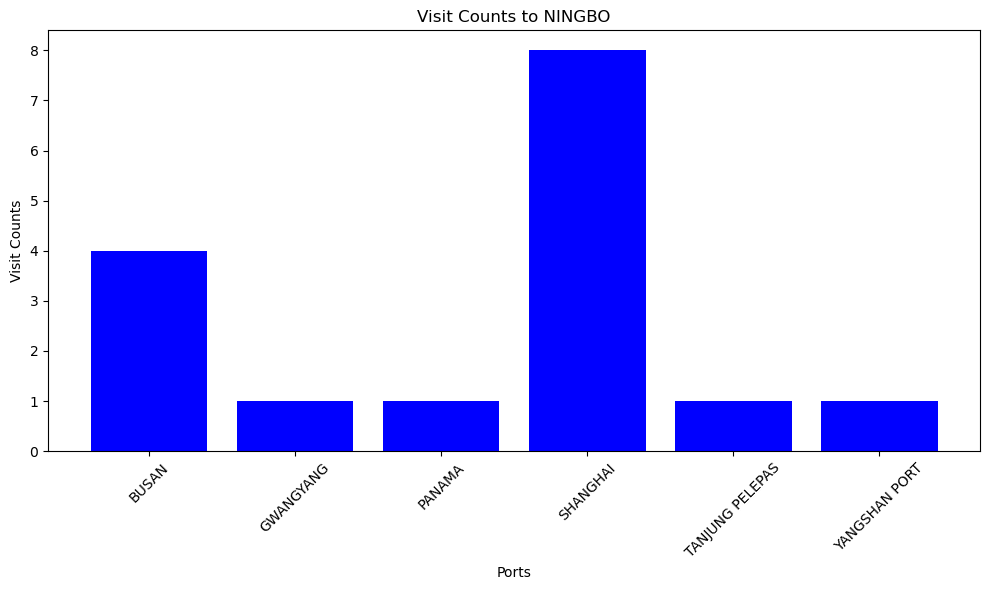

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming pivot_count is already created as in your previous steps

# Step 1: Get user input for the target port name (in this case, "Ningbo")
target_port = "NINGBO"  # You can modify this to accept user input if needed

# Step 2: Check if the target port exists in the pivot_count DataFrame
if target_port in pivot_count.columns:
    # Step 3: Retrieve the counts for visits to the target port
    visit_counts_to_target = pivot_count[['port', target_port]].copy()
    visit_counts_to_target = visit_counts_to_target[visit_counts_to_target[target_port] > 0]  # Filter out zero counts
    
    # Step 4: Plot the bar chart
    plt.figure(figsize=(10, 6))
    plt.bar(visit_counts_to_target['port'], visit_counts_to_target[target_port], color='blue')
    
    # Add labels and title
    plt.title(f'Visit Counts to {target_port}')
    plt.xlabel('Ports')
    plt.ylabel('Visit Counts')
    plt.xticks(rotation=45)
    plt.tight_layout()  # Adjust layout to prevent clipping
    plt.show()
else:
    print(f"{target_port} not found in the data.")


In [37]:

df_port = df[['port']].dropna().copy()

df_port['next_port'] = df_port['port'].shift(-1)

df_port = df_port.dropna(subset=['next_port'])

df_port = df_port[df_port['port'] != df_port['next_port']]

port_counts = df_port['port'].value_counts().reset_index()
port_counts.columns = ['port', 'count']

most_visited_port = port_counts.loc[port_counts['count'].idxmax()]

print("Most Visited Port:")
print(most_visited_port)


Most Visited Port:
port     SUEZ
count      58
Name: 0, dtype: object


In [40]:
# Write the output to Excel without the index column
pivot_count.to_excel('transitions_matrix_count.xlsx')

print("Excel file with unique port count transitions has been created without the index column.")


Excel file with unique port count transitions has been created without the index column.


# Count wise probability

In [42]:
import pandas as pd

df_in_port = df[['port']].dropna().copy()

# Step 2: Create 'next_port' column by shifting the 'port' column
df_in_port['next_port'] = df_in_port['port'].shift(-1)

# Step 3: Remove rows where 'next_port' is NaN (since the last row doesn't have a next port)
df_in_port = df_in_port.dropna(subset=['next_port'])

# Step 4: Filter out rows where 'port' is the same as 'next_port'
df_in_port = df_in_port[df_in_port['port'] != df_in_port['next_port']]

# Step 5: Group by 'port' and 'next_port' to get counts of each transition
visit_counts = df_in_port.groupby(['port', 'next_port']).size().reset_index(name='count')

# Step 6: Create a pivot table where rows are 'port' and columns are 'next_port'
pivot_count = visit_counts.pivot(index='port', columns='next_port', values='count').fillna(0)

# Step 7: For each port (row), calculate the probability by dividing each value by the row sum (total transitions for that port)
pivot_probability = pivot_count.div(pivot_count.sum(axis=1), axis=0)


pivot_probability

next_port,ABIDJAN,ABU DHABI,AD DAMMAM,ANTWERP,BARCELO,BARCELONA,BEIRUT,BREMERHAVEN,BUSAN,CAUCEDO,...,TRIESTE,UMM QASR PT,VALENCIA,VANCOUVER,VUNG TAU,XIAMEN,YANGSHAN PORT,YANTIAN,YEOSU,ZHOUSHAN
port,,,,,,,,,,,,,,,,,,,,,
ABIDJAN,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ABU DHABI,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.222222,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AD DAMMAM,0.0,0.285714,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.571429,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ANTWERP,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.034483,0.0,0.0,0.0,0.0,0.0,0.0,0.0
BARCELO,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XIAMEN,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
YANGSHAN PORT,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
YANTIAN,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [43]:
# Write the output to Excel without the index column
pivot_probability.to_excel('transitions_matrix_probability__count.xlsx')

print("Excel file with unique port probability transitions has been created without the index column.")


Excel file with unique port probability transitions has been created without the index column.


# Network grapgh

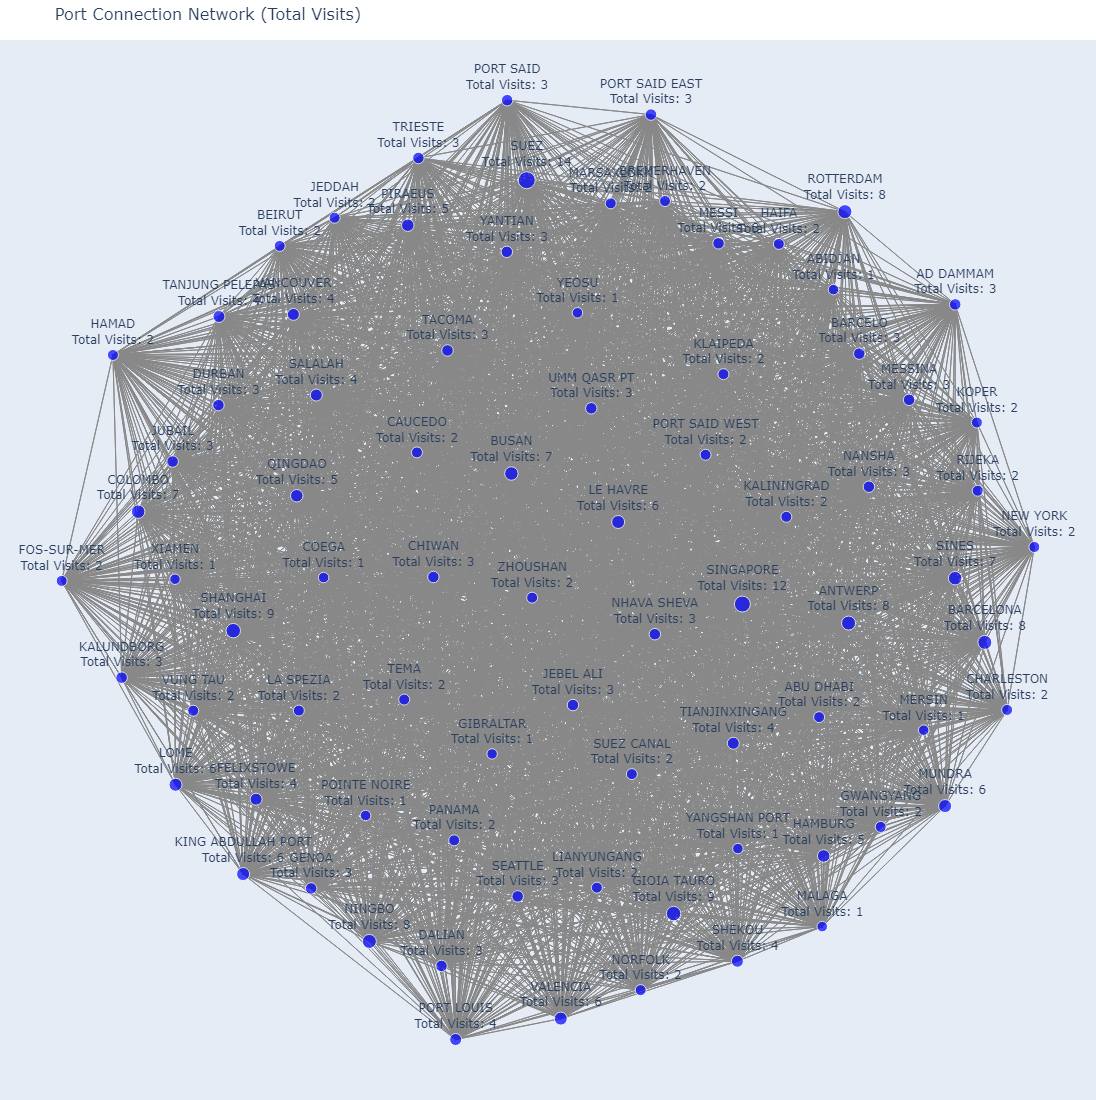

In [45]:
import pandas as pd
import networkx as nx
import plotly.graph_objects as go

df_in_port = df[['port']].copy()
df_in_port['next_port'] = df_in_port['port'].shift(-1)

# Drop rows where next_port is NaN (end of trip)
df_in_port = df_in_port.dropna(subset=['next_port'])

# Drop duplicates to keep only unique connections
df_in_port = df_in_port.drop_duplicates(subset=['port', 'next_port'])

# Create visitation count DataFrame
visit_counts = df_in_port.groupby(['port', 'next_port']).size().reset_index(name='count')

# Count total visits for each port
total_visits = df_in_port['port'].value_counts().reset_index()
total_visits.columns = ['port', 'total_count']

# Step 2: Create a directed graph
G = nx.DiGraph()

# Add nodes to the graph with total visits
for index, row in total_visits.iterrows():
    G.add_node(row['port'], total_count=row['total_count'])  # Each node has its total visits

# Create edges based on the visit counts
for index, row in visit_counts.iterrows():
    G.add_edge(row['port'], row['next_port'], weight=row['count'])  # Add weights for edge thickness

# Ensure all unique ports are added as nodes, even those not visited
for port in df['port'].dropna().unique():
    if port not in G:
        G.add_node(port)

# Connect every port to every other port (complete graph for illustration)
for port1 in total_visits['port']:
    for port2 in total_visits['port']:
        if port1 != port2:
            # Check if there is no existing edge and add a dummy edge with count 1
            if not G.has_edge(port1, port2):
                G.add_edge(port1, port2, weight=1)  # Adding edges for visualization

# Get positions for the nodes using a layout algorithm
pos = nx.spring_layout(G)

# Create edge traces
edge_traces = []
for edge in G.edges(data=True):
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    
    edge_traces.append(go.Scatter(
        x=[x0, x1, None],  # Break line
        y=[y0, y1, None],  # Break line
        line=dict(width=edge[2]['weight'], color='#888'),  # Width based on visitation count
        hoverinfo='none',
        mode='lines'
    ))

# Create node trace
node_x = []
node_y = []
node_text = []

# Update this loop to use 'total_count' correctly
for node in G.nodes(data=True):
    x, y = pos[node[0]]
    node_x.append(x)
    node_y.append(y)
    # Accessing the correct attribute for the total count
    total_count = node[1].get("total_count", 0)  # Default to 0 if not found
    node_text.append(f'{node[0]}<br>Total Visits: {total_count}')

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',
    hoverinfo='text',
    marker=dict(
        showscale=False,  # No color scale needed
        size=[10 + 0.5 * node[1].get("total_count", 0) for node in G.nodes(data=True)],  # Size based on total visits
        color='blue',  # Fixed color for all nodes
    ),
    text=node_text,
    textposition='top center'  # Position the text above the nodes
)

# Create the figure with all edge traces and the node trace
fig = go.Figure(data=edge_traces + [node_trace],  # Combine edge traces with the node trace
                 layout=go.Layout(
                     title='Port Connection Network (Total Visits)',
                     titlefont_size=16,
                     showlegend=False,
                     hovermode='closest',
                     margin=dict(b=0, l=0, r=0, t=40),
                     xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                     width=1100,  # Increased width
                     height=1100,
                     yaxis=dict(showgrid=False, zeroline=False, showticklabels=False))
                 )

# Show the plot
fig.show()


# Network port for Ningbho port only

In [48]:
# Step 1: Create a copy of the DataFrame to work on transitions
df_in_port = df[['port']].copy()

# Step 2: Remove consecutive duplicates (consecutive port visits should not be double counted)
df_in_port = df_in_port[df_in_port['port'] != df_in_port['port'].shift()]

# Step 3: Initialize a list to store the next valid port, skipping any gaps or NaN values
next_ports = []

# Step 4: Loop through the DataFrame to find the next valid port, skipping NaN values
for i in range(len(df_in_port)):
    current_port = df_in_port.iloc[i]['port']
    next_port = None
    
    # Look ahead to find the next valid port, skipping over gaps or NaNs
    for j in range(i + 1, len(df_in_port)):
        if pd.notna(df_in_port.iloc[j]['port']):
            next_port = df_in_port.iloc[j]['port']
            break
    
    # Append the next valid port, or None if no valid port is found
    next_ports.append(next_port)

# Step 5: Add the 'next_port' column to the DataFrame
df_in_port['next_port'] = next_ports

# Step 6: Drop rows where 'next_port' is NaN (to exclude incomplete transitions)
df_in_port = df_in_port.dropna(subset=['next_port'])

# Step 7: Calculate the counts of transitions between ports
visit_counts = df_in_port.groupby(['port', 'next_port']).size().reset_index(name='count')

# Step 8: Filter for transitions involving 'NINGBO' as either 'port' or 'next_port'
ningbo_data = visit_counts[(visit_counts['port'] == 'NINGBO') | (visit_counts['next_port'] == 'NINGBO')]

# Display the results
ningbo_data


,port,next_port,count
29,BUSAN,NINGBO,4
69,GWANGYANG,NINGBO,1
124,NINGBO,BUSAN,1
125,NINGBO,CHIWAN,1
126,NINGBO,NANSHA,3
127,NINGBO,SHANGHAI,3
128,NINGBO,SHEKOU,4
129,NINGBO,SINGAPORE,1
130,NINGBO,XIAMEN,1
131,NINGBO,YANTIAN,2


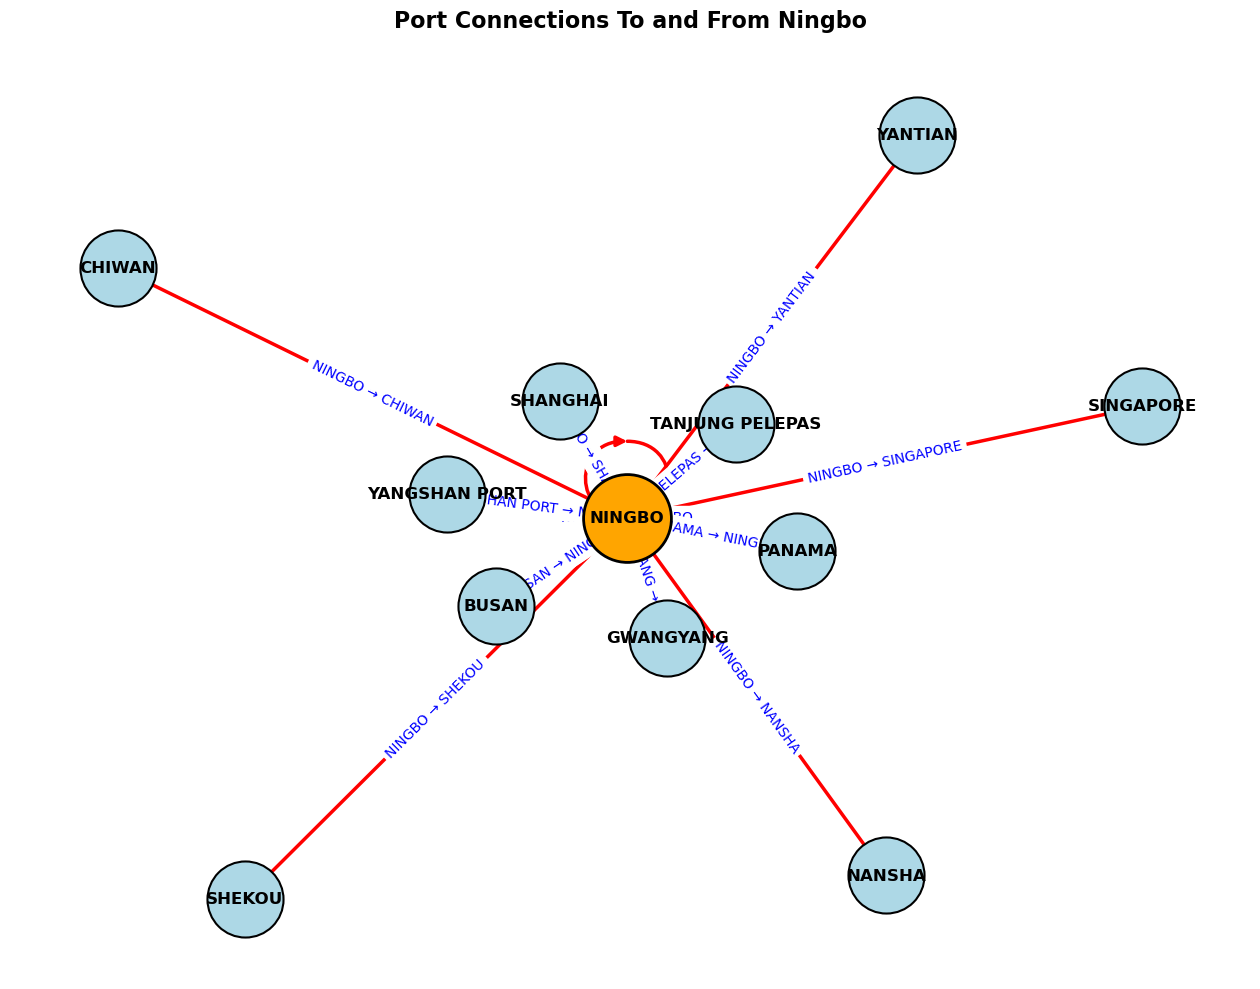

In [49]:
import matplotlib.pyplot as plt
import networkx as nx

# Step 1: Create a subset with the 'port' column
df_in_port = df[['port']].copy()

# Step 2: Create the 'next_port' column by shifting the 'port' column to get the next port in the sequence
df_in_port['next_port'] = df_in_port['port'].shift(-1)

# Step 3a: Filter rows where the next port is 'NINGBO' (i.e., arriving at Ningbo)
to_ningbo_travel = df_in_port[df_in_port['next_port'] == 'NINGBO']

# Step 3b: Filter rows where the current port is 'NINGBO' (i.e., departing from Ningbo)
from_ningbo_travel = df_in_port[df_in_port['port'] == 'NINGBO']

# Step 4: Drop rows with missing ports and duplicates
to_ningbo_travel = to_ningbo_travel.dropna(subset=['port'])
to_ningbo_travel = to_ningbo_travel.drop_duplicates(subset=['port', 'next_port'])

from_ningbo_travel = from_ningbo_travel.dropna(subset=['next_port'])
from_ningbo_travel = from_ningbo_travel.drop_duplicates(subset=['port', 'next_port'])

# Step 5: Create a directed graph to handle both directions (to and from Ningbo)
G = nx.DiGraph()

# Add edges for ports that travel to Ningbo
for _, row in to_ningbo_travel.iterrows():
    G.add_edge(row['port'], row['next_port'])

# Add edges for ports that depart from Ningbo
for _, row in from_ningbo_travel.iterrows():
    G.add_edge(row['port'], row['next_port'])

# Step 6: Draw the graph with enhancements
plt.figure(figsize=(16, 12))

# Use spring layout for a balanced, natural visual appearance
pos = nx.spring_layout(G, k=0.5)  # k controls the distance between nodes

# Draw the nodes
nx.draw_networkx_nodes(G, pos, 
                       node_color='lightblue', 
                       node_size=3000, 
                       edgecolors='black', 
                       linewidths=1.5)

# Highlight Ningbo node
nx.draw_networkx_nodes(G, pos, 
                       nodelist=['NINGBO'], 
                       node_color='orange', 
                       node_size=4000, 
                       edgecolors='black', 
                       linewidths=2)

# Draw the edges with colors and thickness
edge_colors = ['red' if 'NINGBO' in (u, v) else 'gray' for u, v in G.edges()]
edge_widths = [2.5 if 'NINGBO' in (u, v) else 1.5 for u, v in G.edges()]

nx.draw_networkx_edges(G, pos, 
                       arrowstyle='-|>', 
                       arrowsize=15, 
                       edge_color=edge_colors, 
                       width=edge_widths)

# Draw the labels with proper font size
nx.draw_networkx_labels(G, pos, 
                        font_size=12, 
                        font_color='black', 
                        font_weight='bold')

# Add edge labels (optional, to show route names)
edge_labels = {(u, v): f"{u} → {v}" for u, v in G.edges() if 'NINGBO' in (u, v)}
nx.draw_networkx_edge_labels(G, pos, 
                             edge_labels=edge_labels, 
                             font_color='blue', 
                             font_size=10)

# Set title and display the graph
plt.title('Port Connections To and From Ningbo', fontsize=16, fontweight='bold', pad=20)
plt.axis('off')  # Turn off the axis
plt.show()


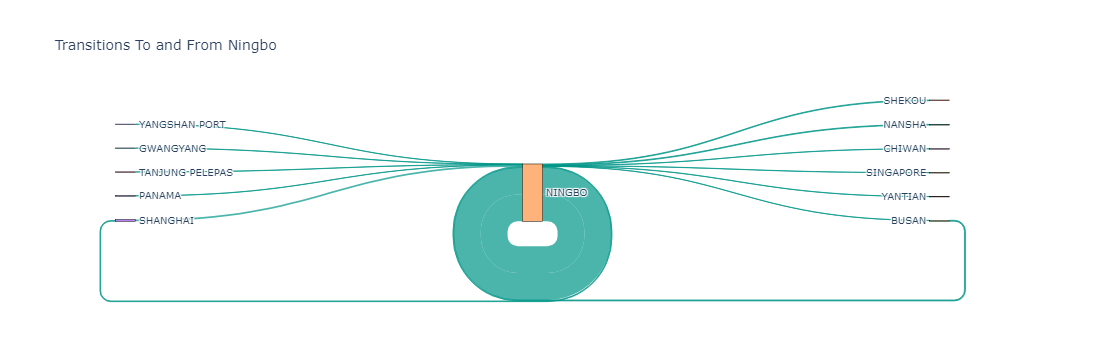

In [50]:
import pandas as pd
import plotly.graph_objects as go

# Step 1: Create a subset with the 'port' column
df_in_port = df[['port']].copy()

# Create a 'next_port' column by shifting the 'port' column
df_in_port['next_port'] = df_in_port['port'].shift(-1)

# Filter for transitions from Ningbo
ningbo_data = df_in_port[df_in_port['port'] == 'NINGBO']

# Drop rows where 'next_port' is NaN
ningbo_data = ningbo_data.dropna(subset=['next_port'])

# Initialize lists for source, target, and values
source_ports = []
target_ports = []
values = []

# Process transitions from Ningbo to other ports
if not ningbo_data.empty:
    ningbo_summary = ningbo_data['next_port'].value_counts().reset_index()
    ningbo_summary.columns = ['next_port', 'count']  # Rename columns for clarity

    # Add to source and target lists
    source_ports += ['NINGBO'] * len(ningbo_summary)  # Source is always 'NINGBO'
    target_ports += ningbo_summary['next_port'].tolist()
    values += ningbo_summary['count'].tolist()

# Process reverse transitions (from other ports to Ningbo)
reverse_summary = df_in_port[df_in_port['next_port'] == 'NINGBO']['port'].value_counts().reset_index()
reverse_summary.columns = ['port', 'count']  # Rename columns for clarity

if not reverse_summary.empty:
    reverse_source_ports = reverse_summary['port'].tolist()
    reverse_values = reverse_summary['count'].tolist()

    # Add reverse transitions to source and target lists
    source_ports += reverse_source_ports  # Source is other ports
    target_ports += ['NINGBO'] * len(reverse_source_ports)  # Target is always 'NINGBO'
    values += reverse_values  # Add counts for reverse transitions

# Create a list of all unique port labels for the nodes
unique_ports = list(set(source_ports).union(set(target_ports)))

# Map target_ports to their respective indices in the unique_ports list
target_indices = [unique_ports.index(port) for port in target_ports]

# Map source_ports to their respective indices in the unique_ports list
source_indices = [unique_ports.index(port) for port in source_ports]

# Create the Sankey diagram
fig = go.Figure(go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=unique_ports  # Use the unique port labels
    ),
    link=dict(
        source=source_indices,  # Use the calculated source indices
        target=target_indices,  # Use the calculated target indices
        value=values,  # Link values (counts)
        color='rgba(0, 150, 136, 0.7)'  # Set a color for the links
    )
))

# Update layout and display the figure
fig.update_layout(title_text="Transitions To and From Ningbo", font_size=10)
fig.show()


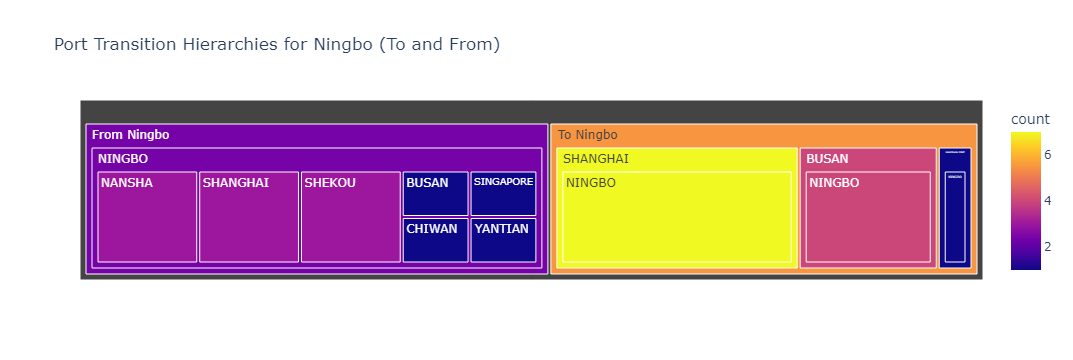

In [51]:
import pandas as pd
import plotly.express as px


df_in_port = df[['port']].copy()

# Step 1: Create 'next_port' column by shifting the 'port' column
df_in_port['next_port'] = df_in_port['port'].shift(-1)

# Step 2: Create a DataFrame for transitions **from** Ningbo
ningbo_from_data = df_in_port[df_in_port['port'] == 'NINGBO']
ningbo_from_data = ningbo_from_data.dropna(subset=['next_port'])

# Step 3: Group 'next_port' for transitions **from** Ningbo
ningbo_from_summary = ningbo_from_data['next_port'].value_counts().reset_index()
ningbo_from_summary.columns = ['next_port', 'count']
ningbo_from_summary['parent_port'] = 'NINGBO'  # Set Ningbo as the parent
ningbo_from_summary['direction'] = 'From Ningbo'  # Add direction column

# Step 4: Create a DataFrame for transitions **to** Ningbo
ningbo_to_data = df_in_port[df_in_port['next_port'] == 'NINGBO']
ningbo_to_summary = ningbo_to_data['port'].value_counts().reset_index()
ningbo_to_summary.columns = ['next_port', 'count']
ningbo_to_summary['parent_port'] = ningbo_to_summary['next_port']  # Set the previous port as the parent
ningbo_to_summary['next_port'] = 'NINGBO'  # Set Ningbo as the target
ningbo_to_summary['direction'] = 'To Ningbo'  # Add direction column

# Step 5: Combine both to/from summaries into one DataFrame
combined_summary = pd.concat([ningbo_from_summary, ningbo_to_summary])

# Step 6: Remove rows where both 'parent_port' and 'next_port' are 'NINGBO'
combined_summary = combined_summary[~((combined_summary['parent_port'] == 'NINGBO') & (combined_summary['next_port'] == 'NINGBO'))]

# Optional: Filter to show only top N transitions
top_n = 10
combined_summary = combined_summary.nlargest(top_n, 'count')

# Step 7: Create a hierarchical Treemap for both to/from transitions
fig = px.treemap(
    combined_summary,
    path=['direction', 'parent_port', 'next_port'],  # Hierarchical path including direction
    values='count',
    title="Port Transition Hierarchies for Ningbo (To and From)",
    color='count',  # Use count for coloring
    hover_data=['count'],  # Show count on hover
)

# Step 8: Show the figure
fig.show()


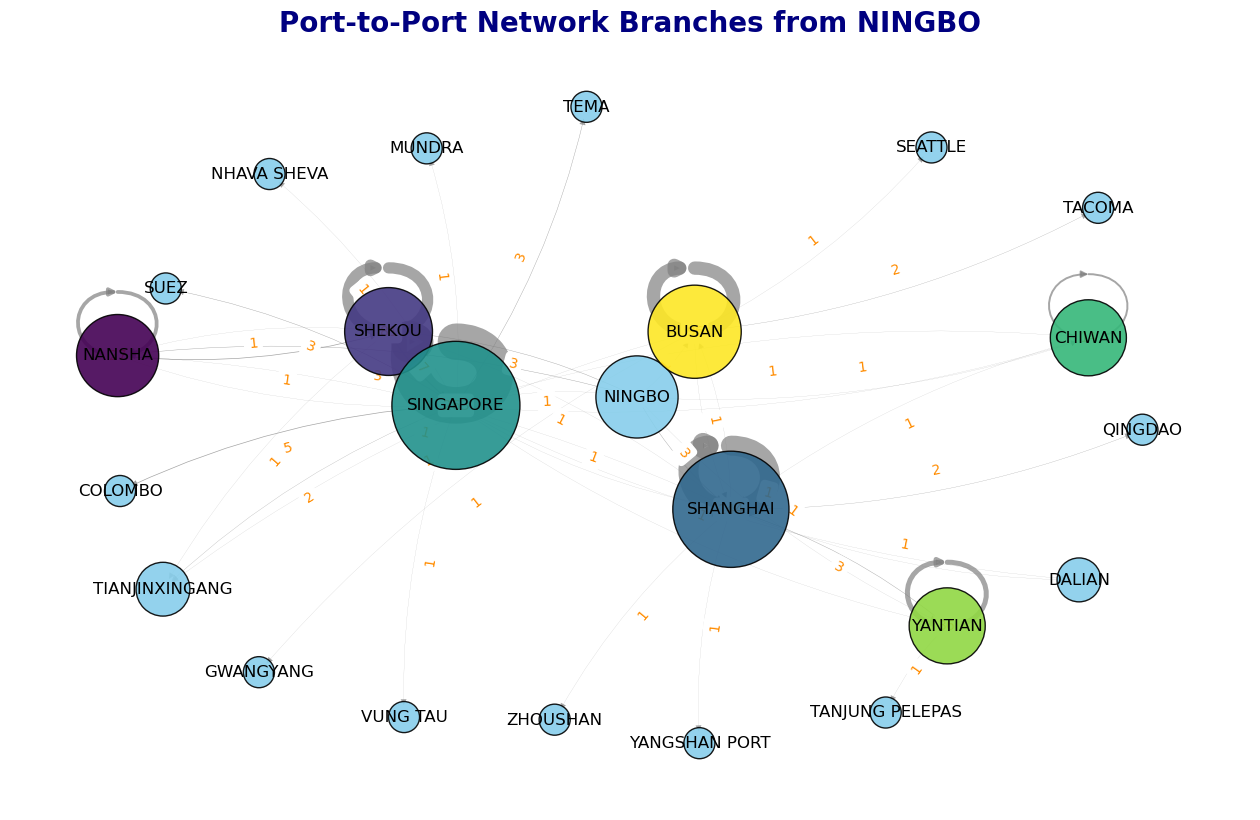

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np


def create_port_network(start_port, node_size_scale=500, edge_alpha=0.7):
    # Step 1: Create 'next_port' column by shifting the 'port' column
    df['next_port'] = df['port'].shift(-1)

    # Step 2: Filter the DataFrame for rows with the starting port
    port_data = df[df['port'] == start_port]

    # Step 3: Drop rows where 'next_port' is NaN
    port_data = port_data.dropna(subset=['next_port'])

    # Step 4: Filter out transitions from the start_port to itself
    port_data = port_data[port_data['next_port'] != start_port]

    # Step 5: Group by 'next_port' and count occurrences
    port_summary = port_data['next_port'].value_counts().reset_index()
    port_summary.columns = ['next_port', 'count']  # Rename columns for clarity

    # Create the directed graph
    G = nx.DiGraph()

    # Add edges with weights (counts) based on port_summary
    for index, row in port_summary.iterrows():
        G.add_edge(start_port, row['next_port'], weight=row['count'])

    # Step 6: Include other outgoing transitions from the next ports
    for port in port_summary['next_port']:
        # Filter the DataFrame for the current port
        next_port_data = df[df['port'] == port]
        
        # Drop rows where 'next_port' is NaN
        next_port_data = next_port_data.dropna(subset=['next_port'])
        
        # Group by 'next_port' and count occurrences
        next_port_summary = next_port_data['next_port'].value_counts().reset_index()
        next_port_summary.columns = ['next_port', 'count']
        
        # Add edges for these transitions to the graph
        for _, next_row in next_port_summary.iterrows():
            if next_row['next_port'] != start_port:  # Exclude self-transition to Ningbo
                G.add_edge(port, next_row['next_port'], weight=next_row['count'])

    # Set node sizes based on degree (number of edges) with scaling for visibility
    node_sizes = [G.degree(node) * node_size_scale for node in G.nodes()]

    # Create a color map for the nodes
    unique_ports = port_summary['next_port'].unique()
    colors = plt.cm.viridis(np.linspace(0, 1, len(unique_ports)))  # Use a colormap

    # Create a mapping of ports to colors
    color_map = {port: colors[i] for i, port in enumerate(unique_ports)}

    # Draw the graph
    plt.figure(figsize=(16, 10), facecolor='white')

    # Position nodes using spring layout with good spacing
    pos = nx.spring_layout(G, k=1.5, iterations=50)

    # Draw nodes with varying sizes and assigned colors
    node_colors = [color_map.get(node, 'skyblue') for node in G.nodes()]  # Default to 'skyblue' for the start_port
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.9, edgecolors='black', linewidths=1)

    # Draw edges with thick arrows for visibility
    edge_widths = [G[u][v]['weight'] / 10 for u, v in G.edges()]  # Scale edge width for visibility
    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=edge_alpha, edge_color='gray', 
                             arrows=True, arrowstyle='-|>', connectionstyle='arc3,rad=0.1')  # No linewidth parameter

    # Draw edge labels (counts) with a better color
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='darkorange', font_size=10)

    # Draw node labels with improved aesthetics
    nx.draw_networkx_labels(G, pos, font_size=12, font_family='sans-serif', font_color='black')

    # Title with enhanced aesthetics
    plt.title(f"Port-to-Port Network Branches from {start_port}", fontsize=20, fontweight='bold', color='navy')
    plt.axis('off')  # Turn off the axis
    plt.grid(False)  # Remove grid
    plt.show()

# Example usage
create_port_network('NINGBO')  # For NINGBO


# Probabilty pred of port

In [56]:
import pandas as pd

# Assuming df is your original DataFrame with the 'port' column.

# Step 1: Create a subset with the 'port' column
df_in_port = df[['port']].copy()

# Step 2: Ensure there are no leading/trailing spaces in the 'port' column
df_in_port['port'] = df_in_port['port'].str.strip()

# Step 3: Initialize a list to store the next valid port
next_ports = []

# Step 4: Loop through the DataFrame to find the next valid port, skipping gaps or NaNs
for i in range(len(df_in_port)):
    current_port = df_in_port.iloc[i]['port']
    next_port = None
    
    # Look ahead to find the next valid port, skipping over gaps or NaNs
    for j in range(i + 1, len(df_in_port)):
        if pd.notna(df_in_port.iloc[j]['port']):
            next_port = df_in_port.iloc[j]['port']
            break
    
    # Append the next valid port, or None if no valid port is found
    next_ports.append(next_port)

# Step 5: Add the 'next_port' column to the DataFrame
df_in_port['next_port'] = next_ports

# Step 6: Drop rows where 'next_port' is NaN (to exclude incomplete transitions)
df_in_port = df_in_port.dropna(subset=['next_port'])

# Step 7: Calculate the counts of transitions between ports
transition_counts = df_in_port.groupby(['port', 'next_port']).size().reset_index(name='count')

# Step 8: Calculate the probability for each transition
transition_counts['probability'] = transition_counts.groupby('port')['count'].transform(lambda x: x / x.sum())

# Step 9: Define a function to get the next port based on a given port and probabilities
def predict_next_port(current_port):
    # Get the transition probabilities for the given port
    possible_transitions = transition_counts[(transition_counts['port'] == current_port) & 
                                             (transition_counts['next_port'] != current_port)]
    
    if possible_transitions.empty:
        return f"No data available for port: {current_port}"
    
    # Sort by the highest probability and add rank
    possible_transitions = possible_transitions.sort_values(by='probability', ascending=False)
    possible_transitions['rank'] = range(1, len(possible_transitions) + 1)

    # Display the next ports, their probabilities, counts, and ranks
    print(f"Next port predictions for {current_port}:")
    print(possible_transitions[['next_port', 'count', 'probability', 'rank']])
    
    # Return the most probable next port, its count, and rank
    most_probable = possible_transitions.iloc[0]
    return most_probable['next_port'], most_probable['count'], most_probable['rank']

# Example usage
current_port = 'NINGBO'  # Replace with your port name
next_port, transition_count, rank = predict_next_port(current_port)
print(f"Predicted next port: {next_port} (Count: {transition_count}, Rank: {rank})")


Next port predictions for NINGBO:
     next_port  count  probability  rank
175     SHEKOU      4     0.031496     1
172     NANSHA      3     0.023622     2
174   SHANGHAI      3     0.023622     3
178    YANTIAN      2     0.015748     4
170      BUSAN      1     0.007874     5
171     CHIWAN      1     0.007874     6
176  SINGAPORE      1     0.007874     7
177     XIAMEN      1     0.007874     8
Predicted next port: SHEKOU (Count: 4, Rank: 1)


# Bayes theorem

In [59]:
import pandas as pd


# Step 1: Calculate prior probabilities for transitions from each port
transition_counts['prior'] = transition_counts.groupby('port')['count'].transform(lambda x: x / x.sum())

# Step 2: Define a function to predict the next port using Bayes' Theorem
def predict_next_port_with_bayes(current_port):
    # Get all possible transitions from the current port, excluding same port to itself
    possible_transitions = transition_counts[(transition_counts['port'] == current_port) & 
                                             (transition_counts['next_port'] != current_port)]
    
    if possible_transitions.empty:
        return f"No data available for port: {current_port}"
    
    # Calculate total count of transitions from the current port
    total_count = possible_transitions['count'].sum()
    
    # Calculate likelihood for each transition
    possible_transitions['likelihood'] = possible_transitions['count'] / total_count
    
    # Marginal probability P(E) - This is just the sum of the likelihoods in this context
    P_E = possible_transitions['likelihood'].sum()

    # Apply Bayes' Theorem to calculate posterior probabilities
    possible_transitions['posterior'] = (possible_transitions['count'] / total_count) / P_E

    # Sort by highest posterior probability and rank them
    possible_transitions = possible_transitions.sort_values(by='posterior', ascending=False)
    possible_transitions['rank'] = range(1, len(possible_transitions) + 1)

    # Display the next ports and their probabilities along with counts
    print(f"Next port predictions for {current_port}:")
    print(possible_transitions[['next_port', 'count', 'prior', 'likelihood', 'posterior', 'rank']])
    
    # Return the most probable next port and its count
    most_probable = possible_transitions.iloc[0]
    return most_probable['next_port'], most_probable['count'], most_probable['posterior']

# Example usage
current_port = 'NINGBO'  # Replace with your port name
next_port, transition_count, posterior_prob = predict_next_port_with_bayes(current_port)
print(f"Predicted next port: {next_port} (Count: {transition_count}, Posterior Probability: {posterior_prob})")


Next port predictions for NINGBO:
     next_port  count     prior  likelihood  posterior  rank
175     SHEKOU      4  0.031496      0.2500     0.2500     1
172     NANSHA      3  0.023622      0.1875     0.1875     2
174   SHANGHAI      3  0.023622      0.1875     0.1875     3
178    YANTIAN      2  0.015748      0.1250     0.1250     4
170      BUSAN      1  0.007874      0.0625     0.0625     5
171     CHIWAN      1  0.007874      0.0625     0.0625     6
176  SINGAPORE      1  0.007874      0.0625     0.0625     7
177     XIAMEN      1  0.007874      0.0625     0.0625     8
Predicted next port: SHEKOU (Count: 4, Posterior Probability: 0.25)


C:\Users\akshaya\AppData\Local\Temp\ipykernel_159160\3835395935.py:20: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\akshaya\AppData\Local\Temp\ipykernel_159160\3835395935.py:26: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



# Probability based on other ports

In [61]:

df_copy = df.copy()

# Step 2: Create a 'next_port' column
df_copy['next_port'] = df_copy['port'].shift(-1)

# Step 3: Create a list to store valid next ports
next_ports = []
for i in range(len(df_copy)):
    current_port = df_copy.iloc[i]['port']
    next_port = None
    
    # Look ahead for the next valid port, skipping NaNs
    for j in range(i + 1, len(df_copy)):
        if pd.notna(df_copy.iloc[j]['next_port']):
            next_port = df_copy.iloc[j]['next_port']
            break
            
    # Append the next valid port to the list
    next_ports.append(next_port)

# Add the valid next ports to the DataFrame
df_copy['next_port'] = next_ports

# Step 4: Filter out rows where 'next_port' is NaN
df_copy = df_copy.dropna(subset=['next_port'])

# Step 5: Group by the current 'port' and 'next_port', and count occurrences
transition_counts = df_copy.groupby(['port', 'next_port']).size().reset_index(name='count')

# Step 6: Calculate the probability for each transition
transition_counts['probability'] = transition_counts.groupby('port')['count'].transform(lambda x: x / x.sum())

# Step 7: Define a function to get the next port based on a given port and probabilities
def calculate_port_chain(start_port, num_transitions=3):
    visited_ports = []
    current_port = start_port

    for _ in range(num_transitions):
        # Filter for the current port's transitions, excluding self-transitions
        transition = transition_counts[
            (transition_counts['port'] == current_port) & 
            (transition_counts['next_port'] != current_port)
        ]

        if transition.empty:
            print(f"No further transitions available from {current_port}.")
            break

        # Sort by probability to get the highest probability transition
        transition = transition.sort_values(by='probability', ascending=False)

        # Get the next port and its probability
        next_port = transition.iloc[0]['next_port']
        probability = transition.iloc[0]['probability']
        
        # Add the port to the visited list
        visited_ports.append({
            'Current Port': current_port,
            'Next Port': next_port,
            'Probability': probability
        })

        # Move to the next port
        current_port = next_port

    # Create a DataFrame to display the port chain
    chain_df = pd.DataFrame(visited_ports)
    print(chain_df)
    return chain_df

# Example usage
start_port = 'NINGBO'  
port_chain_df = calculate_port_chain(start_port)


  Current Port  Next Port  Probability
0       NINGBO     SHEKOU     0.062992
1       SHEKOU  SINGAPORE     0.215054
2    SINGAPORE    COLOMBO     0.038062


# FUEL CONSUMPTION

In [59]:
import pandas as pd

port_pairs = []
total_fuel_consumption = []

# Step 2: Loop through the DataFrame to generate port pairs and accumulate fuel consumption
for i in range(len(df)):
    current_row = df.iloc[i]
    
    # Check if current_row is not NaN
    if pd.notna(current_row['port']):
        # Record the current port
        current_port = current_row['port']
        fuel_sum = current_row['me_foc']  # Start with current fuel consumption
        
        # Look ahead to find the next valid port, skipping NaNs
        next_port = None
        
        for j in range(i + 1, len(df)):
            next_row = df.iloc[j]
            if pd.notna(next_row['port']):
                next_port = next_row['port']
                fuel_sum += next_row['me_foc']  # Accumulate fuel consumption
                break  # Exit loop after finding the first valid next port
        
        # Create the port pair if a next_port is found
        if next_port is not None:
            port_pair = f"{current_port} - {next_port}"
            port_pairs.append(port_pair)
            total_fuel_consumption.append(fuel_sum)  # Append total fuel consumption for this pair
        else:
            # If there's no next port found, append None for total fuel
            port_pairs.append(None)
            total_fuel_consumption.append(None)
    else:
        # If current_row is NaN, append None
        port_pairs.append(None)
        total_fuel_consumption.append(None)

# Step 3: Create a new DataFrame for the results
result_df = pd.DataFrame({
    'port_pair': port_pairs,
    'total_me_foc': total_fuel_consumption
})

# Remove rows where port_pair is None
result_df.dropna(subset=['port_pair'], inplace=True)

# Step 4: Save the results to a CSV file
result_df.to_csv('port_fuel_consumption.csv', index=False)

# Display the result DataFrame
print(result_df)


                  port_pair  total_me_foc
0     SINGAPORE - SINGAPORE          15.6
1     SINGAPORE - SINGAPORE           3.0
2     SINGAPORE - SINGAPORE          54.9
3     SINGAPORE - SINGAPORE         181.9
4     SINGAPORE - SINGAPORE         240.2
...                     ...           ...
5470  ABU DHABI - ABU DHABI           NaN
5471  ABU DHABI - ABU DHABI           NaN
5472  ABU DHABI - ABU DHABI           NaN
5473  ABU DHABI - ABU DHABI           NaN
5474  ABU DHABI - ABU DHABI           NaN

[5168 rows x 2 columns]


# Time taken for port to reach

In [81]:
# Step 1: Create a copy of the DataFrame to work on transitions
df_in_port = df[['port', 'report_date_time']].copy()

# Step 2: Remove consecutive duplicates (consecutive port visits should not be double-counted)
df_in_port = df_in_port[df_in_port['port'] != df_in_port['port'].shift()]

# Step 3: Initialize lists to store the next valid port and the time difference
next_ports = []
time_diffs = []

# Step 4: Loop through the DataFrame to find the next valid port and calculate time differences
for i in range(len(df_in_port)):
    current_port = df_in_port.iloc[i]['port']
    current_time = df_in_port.iloc[i]['report_date_time']
    next_port = None
    time_diff = None
    
    # Look ahead to find the next valid port, skipping over gaps or NaNs
    for j in range(i + 1, len(df_in_port)):
        if pd.notna(df_in_port.iloc[j]['port']):
            next_port = df_in_port.iloc[j]['port']
            next_time = df_in_port.iloc[j]['report_date_time']
            
            # Calculate the time difference
            time_diff = next_time - current_time
            break
    
    # Append the next valid port and time difference
    next_ports.append(next_port)
    time_diffs.append(time_diff)

# Step 5: Add the 'next_port' and 'time_diff' columns to the DataFrame
df_in_port['next_port'] = next_ports
df_in_port['time_diff'] = time_diffs

# Step 6: Drop rows where 'next_port' is NaN (to exclude incomplete transitions)
df_in_port = df_in_port.dropna(subset=['next_port'])

# Step 7: Calculate the counts of transitions between ports
visit_counts = df_in_port.groupby(['port', 'next_port']).size().reset_index(name='count')

# Step 8: Add the time difference information to the counts of transitions
visit_counts['total_time'] = df_in_port.groupby(['port', 'next_port'])['time_diff'].sum().reset_index(drop=True)

# Step 9: Filter for transitions involving 'NINGBO' as either 'port' or 'next_port'
ningbo_data = visit_counts[(visit_counts['port'] == 'NINGBO') | (visit_counts['next_port'] == 'NINGBO')]

# Display the results
ningbo_data


,port,next_port,count,total_time
29,BUSAN,NINGBO,4,14 days 19:36:00
69,GWANGYANG,NINGBO,1,2 days 05:30:00
124,NINGBO,BUSAN,1,5 days 01:42:00
125,NINGBO,CHIWAN,1,2 days 15:12:00
126,NINGBO,NANSHA,3,15 days 11:36:00
127,NINGBO,SHANGHAI,3,11 days 19:06:00
128,NINGBO,SHEKOU,4,19 days 10:42:00
129,NINGBO,SINGAPORE,1,7 days 21:00:00
130,NINGBO,XIAMEN,1,2 days 22:00:00
131,NINGBO,YANTIAN,2,7 days 04:30:00


# port connection multi

In [92]:
df=df_filtered[['imo','vessel','corrected_date','report_date_time','status','lat','long','me_foc','cargo_total','total_steaming_time','me_fuel_only_steaming_time','miles_by_gps','speed_by_log',
 'speed_by_gps', 'rpm', 'slip', 'wind_direction', 'wind_speed', 'draft_aft', 'draft_fwd',"eta_port",'port_code','port','steaming_time_me_rsdl_vls',
 'steaming_time_me_rsdl_hs',"manvrng_miles_by_gps",
 'steaming_time_me_rsdl_uls',
 'steaming_time_me_dstlt_vls',
 'steaming_time_me_dstlt_uls',
 'steaming_time_me_tnktnr_dstlt_vls',
 'steaming_time_me_mdo',
 'steaming_time_aux_1',
 'steaming_time_aux_2',
 'steaming_time_aux_3',
 'steaming_time_aux_4',
 'steaming_time_aux_5',
 'steaming_time_sh_gen',
 'steaming_time_tg',
 'fuel_me_rsdl_vls',
 'fuel_me_rsdl_hs',
 'fuel_me_rsdl_uls',
 'fuel_me_dstlt_vls',
 'fuel_me_dstlt_uls',
 'fuel_me_mdo',
 'fuel_me_tnktnr_dstlt_vls',
 'fuel_aux_rsdl_vls',
 'fuel_aux_rsdl_hs',
 'fuel_aux_rsdl_uls',
 'fuel_aux_dstlt_vls',
 'fuel_aux_dstlt_uls',
 'fuel_aux_tnktnr_dstlt_vls',
 'fuel_aux_mdo',
 'fuel_boiler_rsdl_vls',
 'fuel_boiler_rsdl_hs',
 'fuel_boiler_rsdl_uls',
 'fuel_boiler_dstlt_vls',
 'fuel_boiler_dstlt_uls',
 'fuel_boiler_tnktnr_dstlt_vls',
 'fuel_boiler_mdo',
 'power_kw']]

In [94]:
df = df.sort_values(by='report_date_time')



Next port predictions for YEOSU:
    next_port  count  probability  rank
320   QINGDAO      1     0.111111     1
321  SHANGHAI      1     0.111111     2

Predicted next port: QINGDAO (Count: 1, Rank: 1)


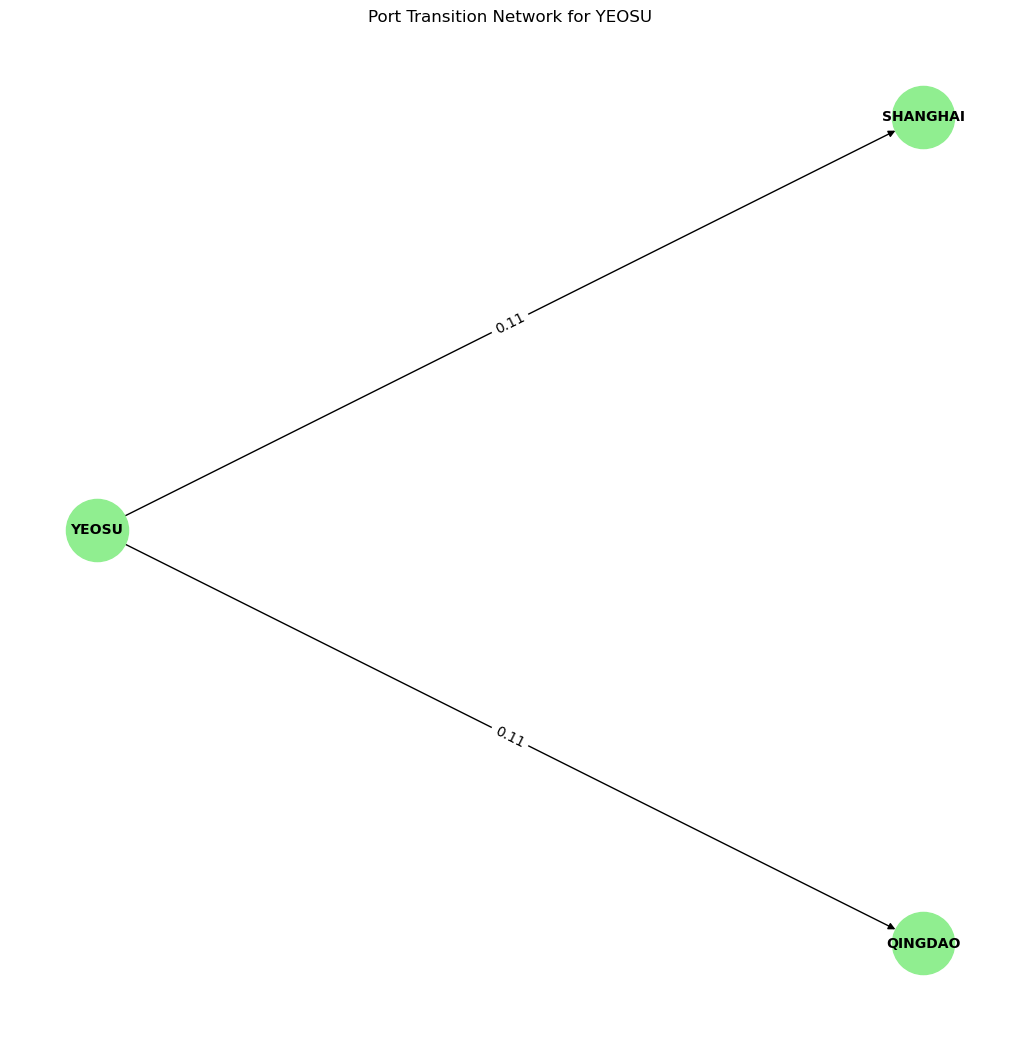

In [96]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Sample DataFrame creation (replace this with your actual DataFrame)
# df = pd.DataFrame({'port': ['Abu Dhabi', 'Port A', None, 'Port B', 'NINGBO', 'Port C', None, 'Port E']})

# Assuming df is already defined and contains the necessary columns
# Step 1: Create a copy of the port column
df_in_port = df[['port']].copy()

# Step 2: Ensure there are no leading/trailing spaces in the 'port' column
df_in_port['port'] = df_in_port['port'].str.strip()

# Step 3: Initialize a list to store the next valid port
next_ports = []

# Step 4: Loop through the DataFrame to find the next valid port, skipping gaps or NaNs
for i in range(len(df_in_port)):
    current_port = df_in_port.iloc[i]['port']
    next_port = None
    
    # Look ahead to find the next valid port, skipping over gaps or NaNs
    for j in range(i + 1, len(df_in_port)):
        if pd.notna(df_in_port.iloc[j]['port']):
            next_port = df_in_port.iloc[j]['port']
            break
    
    # Append the next valid port, or None if no valid port is found
    next_ports.append(next_port)

# Step 5: Add the 'next_port' column to the DataFrame
df_in_port['next_port'] = next_ports

# Step 6: Drop rows where 'next_port' is NaN (to exclude incomplete transitions)
df_in_port = df_in_port.dropna(subset=['next_port'])

# Step 7: Calculate the counts of transitions between ports
transition_counts = df_in_port.groupby(['port', 'next_port']).size().reset_index(name='count')

# Step 8: Calculate the probability for each transition
transition_counts['probability'] = transition_counts.groupby('port')['count'].transform(lambda x: x / x.sum())

# Step 9: Define a function to get the next port based on a given port and probabilities
def predict_next_port(current_port):
    # Get the transition probabilities for the given port
    possible_transitions = transition_counts[(transition_counts['port'] == current_port) & 
                                             (transition_counts['next_port'] != current_port)]
    
    if possible_transitions.empty:
        return None, None, None  # Return None if no transitions are found
    
    # Sort by the highest probability and add rank
    possible_transitions = possible_transitions.sort_values(by='probability', ascending=False)
    possible_transitions['rank'] = range(1, len(possible_transitions) + 1)

    # Display the next ports, their probabilities, counts, and ranks
    print(f"\nNext port predictions for {current_port}:")
    print(possible_transitions[['next_port', 'count', 'probability', 'rank']])
    
    # Return the most probable next port, its count, and rank
    most_probable = possible_transitions.iloc[0]
    return most_probable['next_port'], most_probable['count'], most_probable['rank'], possible_transitions

# User input: Enter the current port name
current_port = 'YEOSU'  # Replace with your port name

# Get predictions for the user-entered port
next_port, transition_count, rank, possible_transitions = predict_next_port(current_port)

# Handle the case where no valid predictions are returned
if next_port is None:
    print(f"\nNo predictions available for the port: {current_port}")
else:
    print(f"\nPredicted next port: {next_port} (Count: {transition_count}, Rank: {rank})")

# Create a directed graph using networkx for visualization
G = nx.DiGraph()

# Add edges to the graph with transition probabilities as weights
for _, row in possible_transitions.iterrows():
    G.add_edge(row['port'], row['next_port'], weight=row['probability'])

# Visualization only for the selected port
plt.figure(figsize=(10, 10))

# Manually specify positions for a structured layout
pos = {current_port: (-1, 0)}  # Position current port on the left

# Set positions for the next ports with equal vertical spacing
num_ports = len(possible_transitions)
for i, port in enumerate(possible_transitions['next_port']):
    pos[port] = (0, i - (num_ports - 1) / 2)  # Center the ports vertically around (0,0)

# Draw the graph
nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightgreen', font_size=10, font_weight='bold', arrows=True)

# Draw edge labels with transition probabilities
edge_labels = nx.get_edge_attributes(G, 'weight')
formatted_edge_labels = {(k[0], k[1]): f'{v:.2f}' for k, v in edge_labels.items()}  # Format the probabilities
nx.draw_networkx_edge_labels(G, pos, edge_labels=formatted_edge_labels)

plt.title(f"Port Transition Network for {current_port}")
plt.axis('off')  # Turn off the axis
plt.show()


Enter the level of prediction (1 for one level, 2 for two levels):  1



Next port predictions for YEOSU:
    next_port  count  probability  rank
320   QINGDAO      1     0.111111     1
321  SHANGHAI      1     0.111111     2


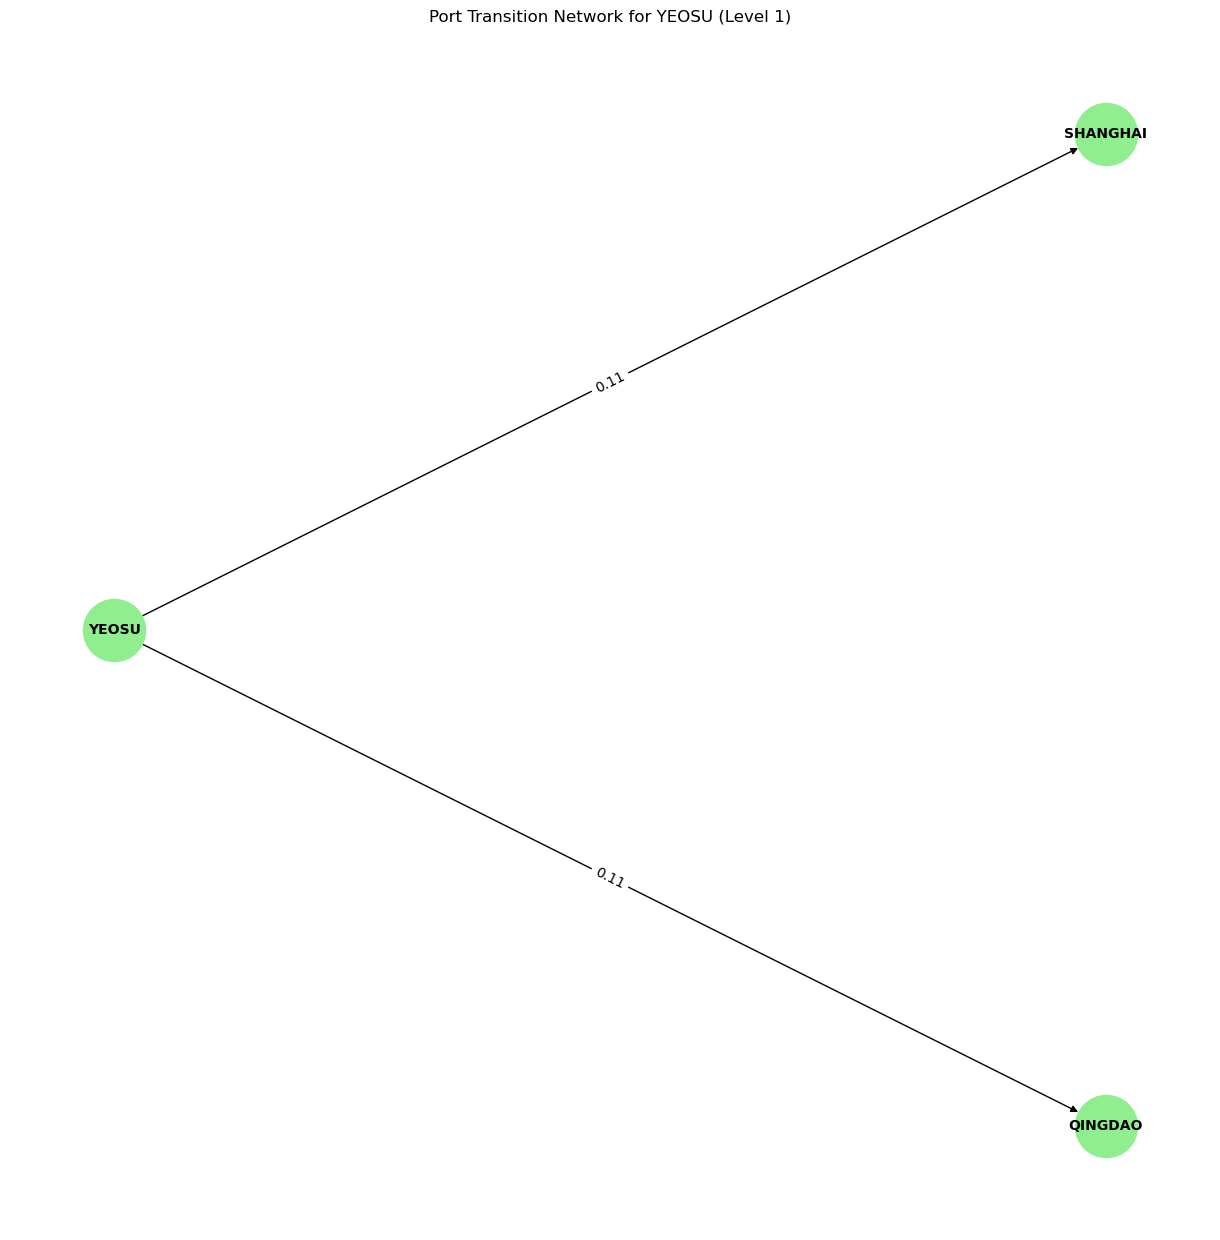

In [97]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Sample DataFrame creation (replace this with your actual DataFrame)
# df = pd.DataFrame({'port': ['Abu Dhabi', 'Port A', None, 'Port B', 'NINGBO', 'Port C', None, 'Port E']})

# Assuming df is already defined and contains the necessary columns
# Step 1: Create a copy of the port column
df_in_port = df[['port']].copy()

# Step 2: Ensure there are no leading/trailing spaces in the 'port' column
df_in_port['port'] = df_in_port['port'].str.strip()

# Step 3: Initialize a list to store the next valid port
next_ports = []

# Step 4: Loop through the DataFrame to find the next valid port, skipping gaps or NaNs
for i in range(len(df_in_port)):
    current_port = df_in_port.iloc[i]['port']
    next_port = None
    
    # Look ahead to find the next valid port, skipping over gaps or NaNs
    for j in range(i + 1, len(df_in_port)):
        if pd.notna(df_in_port.iloc[j]['port']):
            next_port = df_in_port.iloc[j]['port']
            break
    
    # Append the next valid port, or None if no valid port is found
    next_ports.append(next_port)

# Step 5: Add the 'next_port' column to the DataFrame
df_in_port['next_port'] = next_ports

# Step 6: Drop rows where 'next_port' is NaN (to exclude incomplete transitions)
df_in_port = df_in_port.dropna(subset=['next_port'])

# Step 7: Calculate the counts of transitions between ports
transition_counts = df_in_port.groupby(['port', 'next_port']).size().reset_index(name='count')

# Step 8: Calculate the probability for each transition
transition_counts['probability'] = transition_counts.groupby('port')['count'].transform(lambda x: x / x.sum())

# Step 9: Define a function to get the next port based on a given port and probabilities
def predict_next_port(current_port):
    # Get the transition probabilities for the given port
    possible_transitions = transition_counts[(transition_counts['port'] == current_port) & 
                                             (transition_counts['next_port'] != current_port)]
    
    if possible_transitions.empty:
        return None  # Return None if no transitions are found
    
    # Sort by the highest probability and add rank
    possible_transitions = possible_transitions.sort_values(by='probability', ascending=False)
    possible_transitions['rank'] = range(1, len(possible_transitions) + 1)

    # Display the next ports, their probabilities, counts, and ranks
    print(f"\nNext port predictions for {current_port}:")
    print(possible_transitions[['next_port', 'count', 'probability', 'rank']])
    
    return possible_transitions

# User input: Enter the current port name and desired level
current_port = 'YEOSU'  # Replace with your port name
level = int(input("Enter the level of prediction (1 for one level, 2 for two levels): "))

# Get predictions for the user-entered port
possible_transitions = predict_next_port(current_port)

# Handle the case where no valid predictions are returned
if possible_transitions is None:
    print(f"\nNo predictions available for the port: {current_port}")
else:
    # Create a directed graph using networkx for visualization
    G = nx.DiGraph()

    # Add edges for the first level transitions
    for _, row in possible_transitions.iterrows():
        G.add_edge(current_port, row['next_port'], weight=row['probability'])

        # Check if the user wants second level transitions
        if level == 2:
            second_level_transitions = predict_next_port(row['next_port'])
            
            # Add edges for the second level transitions if available
            if second_level_transitions is not None:
                for _, second_row in second_level_transitions.iterrows():
                    # Connect the second level port to the current first level port
                    G.add_edge(row['next_port'], second_row['next_port'], weight=second_row['probability'])

    # Visualization
    plt.figure(figsize=(12, 12))

    # Manually specify positions for a structured layout
    pos = {current_port: (-1, 0)}  # Position current port on the left

    # Set positions for the next ports with equal vertical spacing
    num_ports = len(possible_transitions)
    for i, port in enumerate(possible_transitions['next_port']):
        pos[port] = (0, i - (num_ports - 1) / 2)  # Center the ports vertically around (0,0)

        # Set positions for the second-level ports directly below the first-level ports
        if level == 2:
            second_level_transitions = predict_next_port(port)
            if second_level_transitions is not None:
                num_second_ports = len(second_level_transitions)
                for j, second_port in enumerate(second_level_transitions['next_port']):
                    pos[second_port] = (1, j - (num_second_ports - 1) / 2)  # Directly below first-level port

    # Draw the graph with edges
    nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightgreen', font_size=10, font_weight='bold', arrows=True)

    # Draw edge labels with transition probabilities
    edge_labels = nx.get_edge_attributes(G, 'weight')
    formatted_edge_labels = {(k[0], k[1]): f'{v:.2f}' for k, v in edge_labels.items()}  # Format the probabilities
    nx.draw_networkx_edge_labels(G, pos, edge_labels=formatted_edge_labels)

    plt.title(f"Port Transition Network for {current_port} (Level {level})")
    plt.axis('off')  # Turn off the axis
    plt.show()


Enter the level of prediction (1 for one level, 2 for two levels):  2



Next port predictions for YEOSU:
    next_port  count  probability  rank
320   QINGDAO      1     0.111111     1
321  SHANGHAI      1     0.111111     2

Next port predictions for QINGDAO:
          next_port  count  probability  rank
202           BUSAN      3     0.037975     1
203     LIANYUNGANG      1     0.012658     2
206  TIANJINXINGANG      1     0.012658     3

Next port predictions for SHANGHAI:
         next_port  count  probability  rank
228         NINGBO      8     0.049383     1
227         NANSHA      2     0.012346     2
233       ZHOUSHAN      2     0.012346     3
225          BUSAN      1     0.006173     4
226         DALIAN      1     0.006173     5
231         SHEKOU      1     0.006173     6
232  YANGSHAN PORT      1     0.006173     7

Next port predictions for QINGDAO:
          next_port  count  probability  rank
202           BUSAN      3     0.037975     1
203     LIANYUNGANG      1     0.012658     2
206  TIANJINXINGANG      1     0.012658     3

Next por

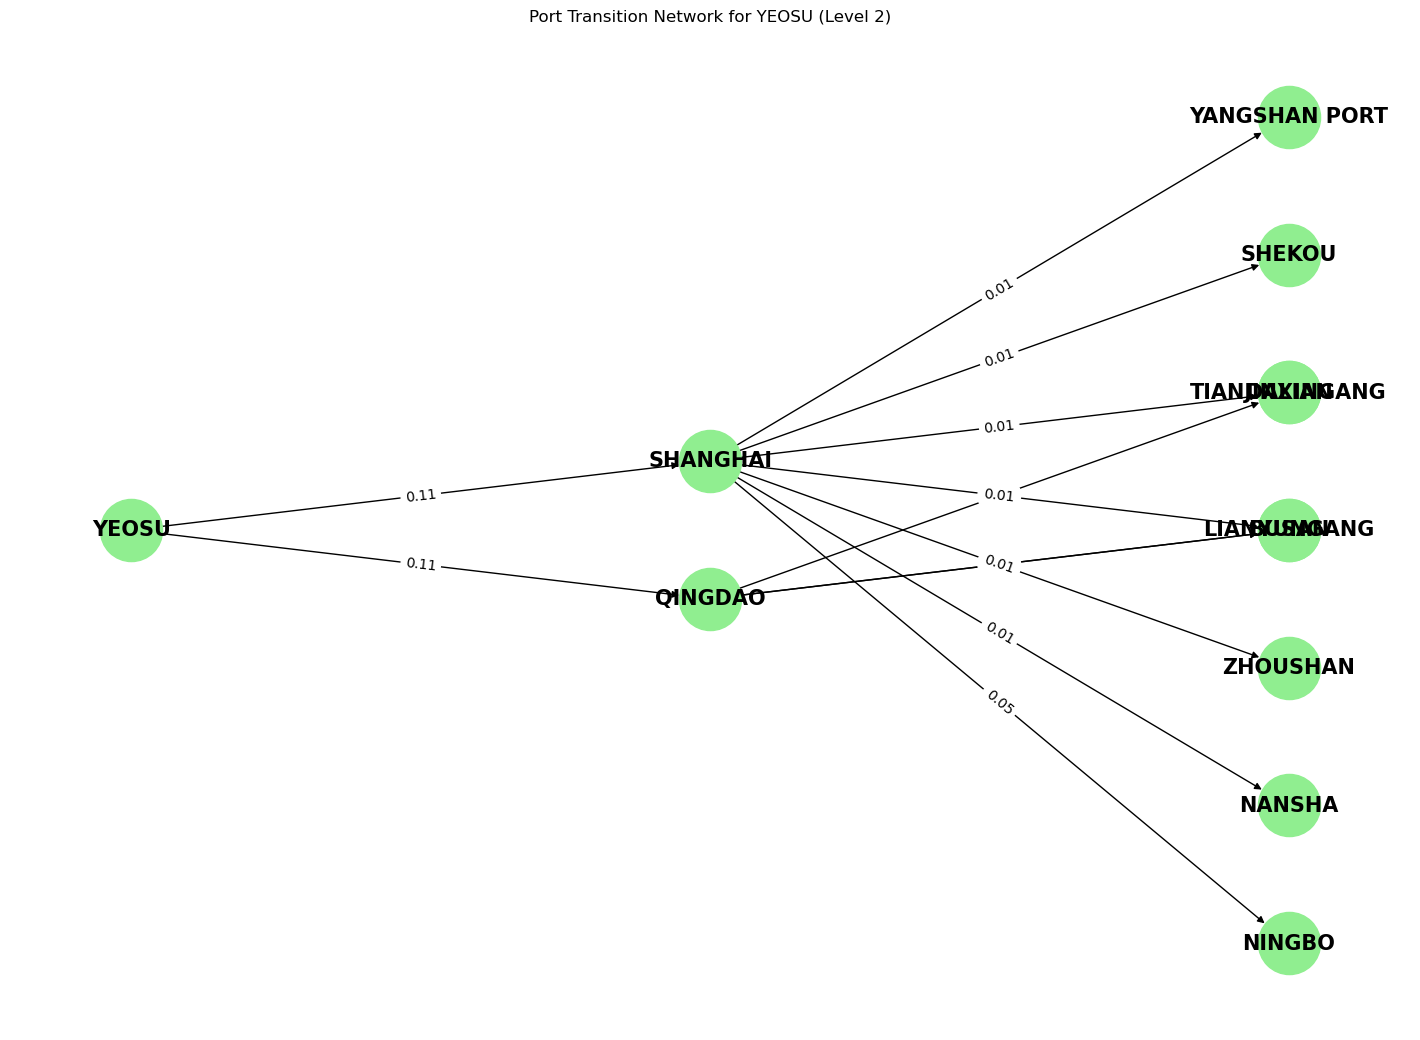


Top Paths with Highest Probabilities:
1. Path: YEOSU -> QINGDAO, Cumulative Probability: 0.1111
2. Path: YEOSU -> SHANGHAI, Cumulative Probability: 0.1111
3. Path: SHANGHAI -> NINGBO, Cumulative Probability: 0.0494


In [98]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Sample DataFrame creation (replace this with your actual DataFrame)
# df = pd.DataFrame({'port': ['Abu Dhabi', 'Shanghai', None, 'Port B', 'NINGBO', 'Port C', None, 'Port E']})

# Assuming df is already defined and contains the necessary columns
# Step 1: Create a copy of the port column
df_in_port = df[['port']].copy()

# Step 2: Ensure there are no leading/trailing spaces in the 'port' column
df_in_port['port'] = df_in_port['port'].str.strip()

# Step 3: Initialize a list to store the next valid port
next_ports = []

# Step 4: Loop through the DataFrame to find the next valid port, skipping gaps or NaNs
for i in range(len(df_in_port)):
    current_port = df_in_port.iloc[i]['port']
    next_port = None
    
    # Look ahead to find the next valid port, skipping over gaps or NaNs
    for j in range(i + 1, len(df_in_port)):
        if pd.notna(df_in_port.iloc[j]['port']):
            next_port = df_in_port.iloc[j]['port']
            break
    
    # Append the next valid port, or None if no valid port is found
    next_ports.append(next_port)

# Step 5: Add the 'next_port' column to the DataFrame
df_in_port['next_port'] = next_ports

# Step 6: Drop rows where 'next_port' is NaN (to exclude incomplete transitions)
df_in_port = df_in_port.dropna(subset=['next_port'])

# Step 7: Calculate the counts of transitions between ports
transition_counts = df_in_port.groupby(['port', 'next_port']).size().reset_index(name='count')

# Step 8: Calculate the probability for each transition
transition_counts['probability'] = transition_counts.groupby('port')['count'].transform(lambda x: x / x.sum())

# Step 9: Define a function to get the next port based on a given port and probabilities
def predict_next_port(current_port, excluded_ports=None):
    # Get the transition probabilities for the given port
    possible_transitions = transition_counts[(transition_counts['port'] == current_port) & 
                                             (transition_counts['next_port'] != current_port)]
    
    # Exclude any ports that have been specified
    if excluded_ports:
        possible_transitions = possible_transitions[~possible_transitions['next_port'].isin(excluded_ports)]
    
    if possible_transitions.empty:
        return None  # Return None if no transitions are found
    
    # Sort by the highest probability and add rank
    possible_transitions = possible_transitions.sort_values(by='probability', ascending=False)
    possible_transitions['rank'] = range(1, len(possible_transitions) + 1)

    # Display the next ports, their probabilities, counts, and ranks
    print(f"\nNext port predictions for {current_port}:")
    print(possible_transitions[['next_port', 'count', 'probability', 'rank']])
    
    return possible_transitions

# User input: Enter the current port name and desired level
current_port = 'YEOSU'  # Replace with your port name
level = int(input("Enter the level of prediction (1 for one level, 2 for two levels): "))

# Get predictions for the user-entered port
level_1_ports = predict_next_port(current_port)

# Handle the case where no valid predictions are returned
if level_1_ports is None:
    print(f"\nNo predictions available for the port: {current_port}")
else:
    # Create a directed graph using networkx for visualization
    G = nx.DiGraph()

    # Add edges for the first level transitions
    for _, row in level_1_ports.iterrows():
        G.add_edge(current_port, row['next_port'], weight=row['probability'])

    # List to keep track of Level 1 ports for exclusion from Level 2
    level_1_ports_list = level_1_ports['next_port'].tolist()

    # Check if the user wants second-level transitions
    if level == 2:
        for _, row in level_1_ports.iterrows():
            second_level_transitions = predict_next_port(row['next_port'], excluded_ports=level_1_ports_list)
            
            # Add edges for the second level transitions if available
            if second_level_transitions is not None:
                for _, second_row in second_level_transitions.iterrows():
                    G.add_edge(row['next_port'], second_row['next_port'], weight=second_row['probability'])

    # Visualization
    plt.figure(figsize=(14, 10))

    # Manually specify positions for a structured layout
    pos = {current_port: (-1, 0)}  # Position current port on the left

    # Set positions for the next ports with equal vertical spacing
    num_ports = len(level_1_ports)
    for i, port in enumerate(level_1_ports['next_port']):
        pos[port] = (0, i - (num_ports - 1) / 2)  # Center the ports vertically around (0,0)

        # Set positions for the second-level ports directly below the first-level ports
        if level == 2:
            second_level_transitions = predict_next_port(port, excluded_ports=level_1_ports_list)
            if second_level_transitions is not None:
                num_second_ports = len(second_level_transitions['next_port'])
                for j, second_port in enumerate(second_level_transitions['next_port']):
                    pos[second_port] = (1, j - (num_second_ports - 1) / 2)  # Directly below first-level port

    # Draw the graph with edges
    nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightgreen', font_size=15, font_weight='bold', arrows=True)

    # Draw edge labels with transition probabilities
    edge_labels = nx.get_edge_attributes(G, 'weight')
    formatted_edge_labels = {(k[0], k[1]): f'{v:.2f}' for k, v in edge_labels.items()}  # Format the probabilities
    nx.draw_networkx_edge_labels(G, pos, edge_labels=formatted_edge_labels)

    plt.title(f"Port Transition Network for {current_port} (Level {level})")
    plt.axis('off')  # Turn off the axis
    plt.show()

# Get top paths based on probabilities
def get_top_paths(G, max_depth=3, top_n=3):
    paths = []
    
    for start_port in G.nodes:
        for end_port in G.nodes:
            if start_port != end_port:
                all_paths = nx.all_simple_paths(G, source=start_port, target=end_port, cutoff=max_depth)
                for path in all_paths:
                    prob = 1.0
                    for i in range(len(path) - 1):
                        prob *= G[path[i]][path[i + 1]]['weight']
                    paths.append((path, prob))

    # Sort paths by cumulative probability
    sorted_paths = sorted(paths, key=lambda x: x[1], reverse=True)
    return sorted_paths[:top_n]

# Get top paths
top_paths = get_top_paths(G, max_depth=2 if level == 2 else 1, top_n=3)

# Print top paths with probabilities
print("\nTop Paths with Highest Probabilities:")
for i, (path, prob) in enumerate(top_paths, 1):
    print(f"{i}. Path: {' -> '.join(path)}, Cumulative Probability: {prob:.4f}")


Enter the level of prediction (1 for one level, 2 for two levels):  2



Next port predictions for YEOSU:
    next_port  count  probability  rank
320   QINGDAO      1     0.111111     1
321  SHANGHAI      1     0.111111     2

Next port predictions for QINGDAO:
          next_port  count  probability  rank
202           BUSAN      3     0.037975     1
203     LIANYUNGANG      1     0.012658     2
206  TIANJINXINGANG      1     0.012658     3

Next port predictions for SHANGHAI:
         next_port  count  probability  rank
228         NINGBO      8     0.049383     1
227         NANSHA      2     0.012346     2
233       ZHOUSHAN      2     0.012346     3
225          BUSAN      1     0.006173     4
226         DALIAN      1     0.006173     5
231         SHEKOU      1     0.006173     6
232  YANGSHAN PORT      1     0.006173     7

Next port predictions for QINGDAO:
          next_port  count  probability  rank
202           BUSAN      3     0.037975     1
203     LIANYUNGANG      1     0.012658     2
206  TIANJINXINGANG      1     0.012658     3

Next por

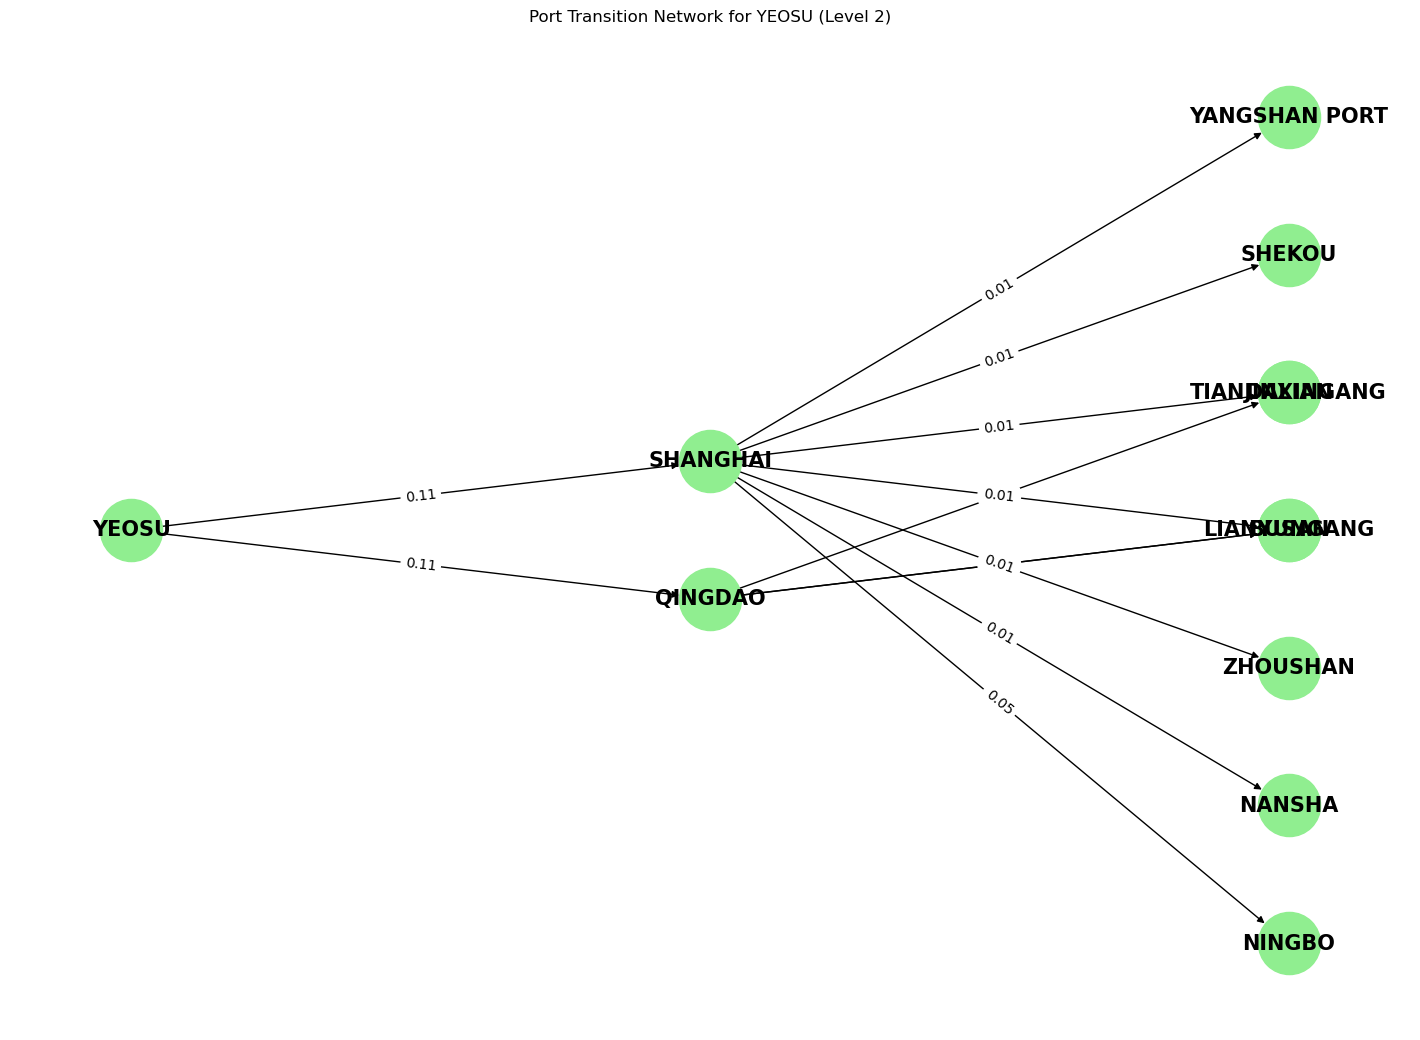


Top Paths with Highest Probabilities:
1. Path: YEOSU -> QINGDAO, Cumulative Probability: 0.1111
2. Path: YEOSU -> SHANGHAI, Cumulative Probability: 0.1111
3. Path: SHANGHAI -> NINGBO, Cumulative Probability: 0.0494


In [99]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Sample DataFrame creation (replace this with your actual DataFrame)
# df = pd.DataFrame({'port': ['Abu Dhabi', 'Shanghai', None, 'Port B', 'NINGBO', 'Port C', None, 'Port E']})

# Assuming df is already defined and contains the necessary columns
# Step 1: Create a copy of the port column
df_in_port = df[['port']].copy()

# Step 2: Ensure there are no leading/trailing spaces in the 'port' column
df_in_port['port'] = df_in_port['port'].str.strip()

# Step 3: Initialize a list to store the next valid port
next_ports = []

# Step 4: Loop through the DataFrame to find the next valid port, skipping gaps or NaNs
for i in range(len(df_in_port)):
    current_port = df_in_port.iloc[i]['port']
    next_port = None
    
    # Look ahead to find the next valid port, skipping over gaps or NaNs
    for j in range(i + 1, len(df_in_port)):
        if pd.notna(df_in_port.iloc[j]['port']):
            next_port = df_in_port.iloc[j]['port']
            break
    
    # Append the next valid port, or None if no valid port is found
    next_ports.append(next_port)

# Step 5: Add the 'next_port' column to the DataFrame
df_in_port['next_port'] = next_ports

# Step 6: Drop rows where 'next_port' is NaN (to exclude incomplete transitions)
df_in_port = df_in_port.dropna(subset=['next_port'])

# Step 7: Calculate the counts of transitions between ports
transition_counts = df_in_port.groupby(['port', 'next_port']).size().reset_index(name='count')

# Step 8: Calculate the probability for each transition
transition_counts['probability'] = transition_counts.groupby('port')['count'].transform(lambda x: x / x.sum())

# Step 9: Define a function to get the next port based on a given port and probabilities
def predict_next_port(current_port, excluded_ports=None):
    # Get the transition probabilities for the given port
    possible_transitions = transition_counts[(transition_counts['port'] == current_port) & 
                                             (transition_counts['next_port'] != current_port)]
    
    # Exclude any ports that have been specified
    if excluded_ports:
        possible_transitions = possible_transitions[~possible_transitions['next_port'].isin(excluded_ports)]
    
    if possible_transitions.empty:
        return None  # Return None if no transitions are found
    
    # Sort by the highest probability and add rank
    possible_transitions = possible_transitions.sort_values(by='probability', ascending=False)
    possible_transitions['rank'] = range(1, len(possible_transitions) + 1)

    # Display the next ports, their probabilities, counts, and ranks
    print(f"\nNext port predictions for {current_port}:")
    print(possible_transitions[['next_port', 'count', 'probability', 'rank']])
    
    return possible_transitions

# User input: Enter the current port name and desired level
current_port = 'YEOSU'  # Replace with your port name
level = int(input("Enter the level of prediction (1 for one level, 2 for two levels): "))

# Get predictions for the user-entered port
level_1_ports = predict_next_port(current_port)

# Handle the case where no valid predictions are returned
if level_1_ports is None:
    print(f"\nNo predictions available for the port: {current_port}")
else:
    # Create a directed graph using networkx for visualization
    G = nx.DiGraph()

    # Add edges for the first level transitions
    for _, row in level_1_ports.iterrows():
        G.add_edge(current_port, row['next_port'], weight=row['probability'])

    # List to keep track of Level 1 ports for exclusion from Level 2
    level_1_ports_list = level_1_ports['next_port'].tolist()

    # Check if the user wants second-level transitions
    if level == 2:
        for _, row in level_1_ports.iterrows():
            second_level_transitions = predict_next_port(row['next_port'], excluded_ports=level_1_ports_list)
            
            # Add edges for the second level transitions if available
            if second_level_transitions is not None:
                for _, second_row in second_level_transitions.iterrows():
                    G.add_edge(row['next_port'], second_row['next_port'], weight=second_row['probability'])

    # Visualization
    plt.figure(figsize=(14, 10))

    # Manually specify positions for a structured layout
    pos = {current_port: (-1, 0)}  # Position current port on the left

    # Set positions for the next ports with equal vertical spacing
    num_ports = len(level_1_ports)
    for i, port in enumerate(level_1_ports['next_port']):
        pos[port] = (0, i - (num_ports - 1) / 2)  # Center the ports vertically around (0,0)

        # Set positions for the second-level ports directly below the first-level ports
        if level == 2:
            second_level_transitions = predict_next_port(port, excluded_ports=level_1_ports_list)
            if second_level_transitions is not None:
                num_second_ports = len(second_level_transitions['next_port'])
                for j, second_port in enumerate(second_level_transitions['next_port']):
                    pos[second_port] = (1, j - (num_second_ports - 1) / 2)  # Directly below first-level port

    # Draw the graph with edges
    nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightgreen', font_size=15, font_weight='bold', arrows=True)

    # Draw edge labels with transition probabilities
    edge_labels = nx.get_edge_attributes(G, 'weight')
    formatted_edge_labels = {(k[0], k[1]): f'{v:.2f}' for k, v in edge_labels.items()}  # Format the probabilities
    nx.draw_networkx_edge_labels(G, pos, edge_labels=formatted_edge_labels)

    plt.title(f"Port Transition Network for {current_port} (Level {level})")
    plt.axis('off')  # Turn off the axis
    plt.show()

# Get top paths based on probabilities
def get_top_paths(G, max_depth=3, top_n=3):
    paths = []
    
    for start_port in G.nodes:
        for end_port in G.nodes:
            if start_port != end_port:
                all_paths = nx.all_simple_paths(G, source=start_port, target=end_port, cutoff=max_depth)
                for path in all_paths:
                    prob = 1.0
                    for i in range(len(path) - 1):
                        prob *= G[path[i]][path[i + 1]]['weight']
                    paths.append((path, prob))

    # Sort paths by cumulative probability
    sorted_paths = sorted(paths, key=lambda x: x[1], reverse=True)
    return sorted_paths[:top_n]

# Get top paths
top_paths = get_top_paths(G, max_depth=2 if level == 2 else 1, top_n=3)

# Print top paths with probabilities
print("\nTop Paths with Highest Probabilities:")
for i, (path, prob) in enumerate(top_paths, 1):
    print(f"{i}. Path: {' -> '.join(path)}, Cumulative Probability: {prob:.4f}")


# makrov chain

In [79]:

df['next_port'] = df.groupby('vessel')['port'].shift(-1)

# Step 2: Drop rows where there is no next port (i.e., last port for each vessel)
df_transitions = df.dropna(subset=['next_port'])

# Step 3: Filter out self-transitions (same port to same port)
df_transitions = df_transitions[df_transitions['port'] != df_transitions['next_port']]

# Step 4: Calculate transition frequencies
transition_counts = df_transitions.groupby(['port', 'next_port']).size().unstack(fill_value=0)

# Step 5: Calculate transition probabilities by normalizing the transition counts
transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0)

transition_matrix


next_port,HAMAD,JUBAIL,UMM QASR PT,FELIXSTOWE,HAMBURG,LE HAVRE,NEW YORK,ROTTERDAM,SINES,VALENCIA,...,DALIAN,YANGSHAN PORT,ZHOUSHAN,VUNG TAU,PORT SAID,PORT SAID EAST,PORT SAID WEST,SUEZ CANAL,RIJEKA,MARSAXLOKK
port,,,,,,,,,,,,,,,,,,,,,
ABU DHABI,1.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AD DAMMAM,0.0,0.2,0.8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ANTWERP,0.0,0.0,0.0,0.034483,0.068966,0.172414,0.034483,0.586207,0.068966,0.034483,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
BARCELO,0.0,0.0,0.0,0.500000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
BARCELONA,0.0,0.0,0.0,0.142857,0.000000,0.357143,0.000000,0.071429,0.214286,0.071429,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VANCOUVER,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
VUNG TAU,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
YANGSHAN PORT,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [81]:

def predict_next_port(current_port, transition_matrix, seed=None):
    if current_port not in transition_matrix.index:
        print(f"No transition data available for {current_port}")
        return None
    
    # Optionally set the random seed for reproducibility
    if seed is not None:
        np.random.seed(seed)
    
    # Get the transition probabilities for the current port
    transition_probs = transition_matrix.loc[current_port].values
    
    # Set the probability of transitioning to the same port (current_port) to zero
    port_index = list(transition_matrix.columns).index(current_port)
    transition_probs[port_index] = 0

    # Check if all probabilities are zero after removing the current port
    if transition_probs.sum() == 0:
        print(f"All transition probabilities for {current_port} are zero.")
        return None

    # Normalize the probabilities again to ensure they sum to 1
    transition_probs = transition_probs / transition_probs.sum()
    
    # Predict the next port based on the updated transition probabilities
    next_port = np.random.choice(transition_matrix.columns, p=transition_probs)
    
    return next_port

# Example usage with your actual transition matrix
current_port = "NINGBO"  # Start at NINGBO
seed_value = 42  # Set a seed for reproducibility

# Use the real transition matrix generated from your data
next_port = predict_next_port(current_port, transition_matrix, seed=seed_value)

if next_port:
    print(f"The vessel is currently at {current_port}. The next predicted port is {next_port}.")


The vessel is currently at NINGBO. The next predicted port is SHEKOU.


In [83]:
transition_matrix.to_csv('transition_matrix.csv')

In [85]:

df['next_port'] = df.groupby('vessel')['port'].shift(-1)

# Drop rows where next_port is NaN (last port for each vessel)
df_transitions = df.dropna(subset=['next_port'])

# Step 2: Create a transition matrix
transition_counts = df_transitions.groupby(['port', 'next_port']).size().unstack(fill_value=0)
transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0)

# Function to predict next port
def predict_next_port(current_port):
    if current_port in transition_matrix.index:
        predicted_next_ports = transition_matrix.loc[current_port].idxmax()  # Get the port with the highest probability
        return predicted_next_ports
    else:
        return None

# Step 3: Make predictions
df_transitions['predicted_next_port'] = df_transitions['port'].apply(predict_next_port)

# Step 4: Compare predictions with actual next ports
df_transitions['correct_prediction'] = df_transitions['predicted_next_port'] == df_transitions['next_port']

# Step 5: Calculate accuracy
accuracy = df_transitions['correct_prediction'].mean() * 100  # Convert to percentage

# Display results
print("Predictions:")
print(df_transitions[['port', 'next_port', 'predicted_next_port', 'correct_prediction']])
print(f"Prediction Accuracy: {accuracy:.2f}%")


Predictions:
           port  next_port predicted_next_port  correct_prediction
4632  SINGAPORE  SINGAPORE           SINGAPORE                True
4700  SINGAPORE  SINGAPORE           SINGAPORE                True
4873  SINGAPORE  SINGAPORE           SINGAPORE                True
4874  SINGAPORE  SINGAPORE           SINGAPORE                True
4697  SINGAPORE  SINGAPORE           SINGAPORE                True
...         ...        ...                 ...                 ...
473   ABU DHABI  ABU DHABI           ABU DHABI                True
474   ABU DHABI  ABU DHABI           ABU DHABI                True
475   ABU DHABI  ABU DHABI           ABU DHABI                True
476   ABU DHABI  ABU DHABI           ABU DHABI                True
484   ABU DHABI  ABU DHABI           ABU DHABI                True

[5168 rows x 4 columns]
Prediction Accuracy: 87.25%


C:\Users\akshaya\AppData\Local\Temp\ipykernel_60704\776251663.py:19: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\akshaya\AppData\Local\Temp\ipykernel_60704\776251663.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [86]:
df_transitions.to_csv('predicitions.csv')

# PORT INBETWEEN

In [85]:
import networkx as nx

# Create a directed graph
port_graph = nx.DiGraph()

# Add edges between ports based on your DataFrame df_in_port
for i in range(len(df_in_port)):
    port = df_in_port.iloc[i]['port']
    next_port = df_in_port.iloc[i]['next_port']
    
    # Add the port transition as an edge in the graph
    port_graph.add_edge(port, next_port)


In [87]:
# Define a function to find the path between two ports
def find_path_between_ports(source_port, destination_port):
    try:
        # Find the shortest path between the source and destination
        path = nx.shortest_path(port_graph, source=source_port, target=destination_port)
        return path
    except nx.NetworkXNoPath:
        return None  # If no path is found


In [95]:
def get_ports_in_between(source_port, destination_port):
    # Get the path
    path = find_path_between_ports(source_port, destination_port)
    
    if path:
        # Intermediate ports are all ports except the first and last
        intermediate_ports = path[1:-1]
        return intermediate_ports if intermediate_ports else "No intermediate ports."
    else:
        return "No path found between the ports."

# Example usage
source_port = 'SHANGHAI'
destination_port = 'NINGBO'

intermediate_ports = get_ports_in_between(source_port, destination_port)
print(f"Intermediate ports between {source_port} and {destination_port}: {intermediate_ports}")


Intermediate ports between SHANGHAI and NINGBO: No intermediate ports.


In [91]:
# Add weighted edges based on time differences
for i in range(len(df_in_port)):
    port = df_in_port.iloc[i]['port']
    next_port = df_in_port.iloc[i]['next_port']
    time_diff = df_in_port.iloc[i]['time_diff'].total_seconds()  # Use seconds for weighting
    
    # Add the port transition as an edge with time as the weight
    port_graph.add_edge(port, next_port, weight=time_diff)
    
# Define a function to find the shortest path between ports based on time
def find_shortest_path_by_time(source_port, destination_port):
    try:
        # Find the shortest path based on weight (time)
        path = nx.shortest_path(port_graph, source=source_port, target=destination_port, weight='weight')
        return path
    except nx.NetworkXNoPath:
        return None  # If no path is found

# Example usage for finding shortest path based on travel time
path = find_shortest_path_by_time('SHANGHAI', 'NINGBO')
print(f"Shortest path based on time between SHANGHAI and NINGBO: {path}")


Shortest path based on time between SHANGHAI and NINGBO: ['SHANGHAI', 'YANGSHAN PORT', 'NINGBO']


In [143]:
import pandas as pd
import networkx as nx

# Step 1: Create a graph representation of the port transitions
def create_port_graph(df_in_port):
    port_graph = nx.DiGraph()  # Directed graph
    
    # Add edges based on the port transitions from the DataFrame
    for i in range(len(df_in_port)):
        port = df_in_port.iloc[i]['port']
        next_port = df_in_port.iloc[i]['next_port']
        
        # Ensure that both 'port' and 'next_port' are not None before adding to the graph
        if pd.notna(port) and pd.notna(next_port):
            port_graph.add_edge(port, next_port)
    
    return port_graph

# Step 2: Find the shortest path between two ports
def find_path_between_ports(port_graph, source_port, destination_port):
    try:
        # Find the shortest path between source_port and destination_port
        path = nx.shortest_path(port_graph, source=source_port, target=destination_port)
        return path
    except nx.NetworkXNoPath:
        return None  # If no path is found

# Step 3: Function to get intermediate ports, including connections
def get_ports_in_between_with_connections(port_graph, source_port, destination_port):
    # Get the direct path first
    direct_path = find_path_between_ports(port_graph, source_port, destination_port)
    
    if direct_path:
        # Intermediate ports are all ports except the first and last
        intermediate_ports = direct_path[1:-1]
        return intermediate_ports if intermediate_ports else "No intermediate ports."
    
    # If no direct path is found, search for possible connecting ports
    possible_routes = []
    
    # Loop through all available ports to find potential connecting ports
    for port in port_graph.nodes:
        if port != source_port and port != destination_port:
            # Try to find a path from source_port to the current port
            path_to_intermediate = find_path_between_ports(port_graph, source_port, port)
            
            # Try to find a path from the current port to the destination_port
            path_from_intermediate = find_path_between_ports(port_graph, port, destination_port)
            
            # If both paths exist, it's a valid connection
            if path_to_intermediate and path_from_intermediate:
                # Combine both paths to form a full journey
                full_path = path_to_intermediate[:-1] + path_from_intermediate
                possible_routes.append(full_path)
    
    # If possible connecting routes were found, return them
    if possible_routes:
        return possible_routes
    else:
        return "No route found, even with connections."

df_in_port = df[['port']].copy()

next_ports = []

# Step 6: Loop through the DataFrame to find the next valid port, skipping gaps or NaNs
for i in range(len(df_in_port)):
    current_port = df_in_port.iloc[i]['port']
    next_port = None
    
    # Look ahead to find the next valid port, skipping over gaps or NaNs
    for j in range(i + 1, len(df_in_port)):
        if pd.notna(df_in_port.iloc[j]['port']):
            next_port = df_in_port.iloc[j]['port']
            break
    
    # Append the next valid port, or None if no valid port is found
    next_ports.append(next_port)

# Step 7: Add the 'next_port' column to the DataFrame
df_in_port['next_port'] = next_ports

# Create the port graph
port_graph = create_port_graph(df_in_port)

# Step 8: Example usage of the function
source_port = 'SHANGHAI'
destination_port = 'BUSAN'

# Get possible routes with connections
routes = get_ports_in_between_with_connections(port_graph, source_port, destination_port)

# Step 9: Display the results
if isinstance(routes, list):
    for idx, route in enumerate(routes):
        print(f"Route {idx+1}: {' -> '.join(route)}")
else:
    print(routes)


No intermediate ports.


In [ ]:
df['report_date_time'] = pd.to_datetime(df['report_date_time'], errors='coerce')

# Check for any problematic entries after conversion
problematic_entries = df[df['report_date_time'].isna()]

if not problematic_entries.empty:
    print("The following entries could not be converted to datetime:")
    print(problematic_entries[['report_date_time']])

# Step 2: Filter the DataFrame for 'IN PORT' status
df_in_port = df[df['status'] == 'IN PORT']

# Step 3: Initialize a new column for travel duration
df['travel_duration_hours'] = None

# Step 4: Loop through the filtered DataFrame to calculate travel durations
for i in range(len(df_in_port) - 1):
    current_row = df_in_port.iloc[i]
    next_row = df_in_port.iloc[i + 1]
    
    # Only calculate if the ports are different and if the dates are valid
    if current_row['port'] != next_row['port'] and pd.notna(current_row['report_date_time']) and pd.notna(next_row['report_date_time']):
        # Calculate the travel duration in hours
        travel_duration = (next_row['report_date_time'] - current_row['report_date_time']).total_seconds() / 3600  # Convert seconds to hours
        
        # Set the travel duration in the original DataFrame for the current row
        df.loc[current_row.name, 'travel_duration_hours'] = travel_duration


In [ ]:
df

In [ ]:
df.to_csv('time.csv')

In [ ]:
# Step 2: Filter the DataFrame for 'IN PORT' status
df_in_port = df[df['status'] == 'IN PORT']

# Step 3: Initialize the travel distance column
df['travel_distance'] = None  # Initialize the travel distance column

# Step 4: Loop through the filtered DataFrame to calculate distances
for i in range(len(df_in_port) - 1):
    current_row = df_in_port.iloc[i]
    next_row = df_in_port.iloc[i + 1]
    
    # Only calculate if the ports are different
    if current_row['port'] != next_row['port']:
        # Calculate the distance using miles_by_gps and manvrng_miles_by_gps
        travel_distance = current_row['miles_by_gps'] + current_row['manvrng_miles_by_gps']
        
        # Set the travel distance in the original DataFrame for the current row
        df.loc[current_row.name, 'travel_distance'] = travel_distance


In [ ]:
nan_count_port = df['port'].isna().sum()

# Get unique counts in the port column
unique_count_port = df['port'].nunique()

print(f"NaN Count in 'port' column: {nan_count_port}")
print(f"Unique Count in 'port' column: {unique_count_port}")


In [ ]:
most_frequent_port = df['port'].value_counts().idxmax()
most_frequent_port_count = df['port'].value_counts().max()

print(f"The most frequent port is: {most_frequent_port} with {most_frequent_port_count} occurrences.")


In [ ]:
find how many times the vseesl went from one port to another 